In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.patches import Circle
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import plotly.express as px
import random
from scipy.integrate import solve_ivp
import imageio
import os
import time
import csv
from scipy.stats import poisson
from scipy.stats import chisquare
import math
import pickle
from numba import njit
from numpy import genfromtxt


In [3]:
# Function for random gaussian variable from Box-Muller method. Returns np array of two independent random gaussians
# with 0 mean and 1 variance of length of the argument 


def xi(size):
    e = np.random.uniform(0, 1, (2, size))
    r = np.sqrt(-2 * np.log(e[0]))
    arr = r * np.array([np.cos(2 * np.pi * e[1]), np.sin(2 * np.pi * e[1])])
    return np.column_stack((arr[0], arr[1]))

dt=0.1            #time-step
dx=0.01            #spatial grating

H=1                #dimensions of the box 
L=2

# x and y values helpful in doing grating.
x_values = np.arange(0, L, dx)
y_values = np.arange(0, H, dx) 


# x and y values helpful in doing statistics. "zer" helpful for storing numbers of particles in each gridbox
x_edges = np.arange(0, L + dx, dx)
y_edges = np.arange(0, H + dx, dx)
zer=np.zeros(np.size(x_values)*np.size(y_values))


#physics

C0= 2.1
eps= 0.001


C=0


k=(H*eps)**(2/3)
CT=10
CQ=10
pr=85000      #pressure

w=eps/k
wT=CT*w
wQ=CQ*w







Tt=282
dT=12
Tb=Tt+dT
Tmid=(Tt+Tb)/2

r0 = 10*10**(-6)

beta=C0*eps
sigma = np.sqrt((2/3)*k)
tau=4*k/(3*C0*eps)



def esw(T):
    return(661*np.exp((17.27*(T - 273.15))/((T - 273.15) + 237.7)))
eps2=0.622 #Rd/Rv




#function for supersaturation and initial conditions
ee = 0.622
e0 = 611.73
T0 = 273.16
Rv = 461.5
Lv0 = 2.5*10**6
p0=1013.25 * 10**2

def partialPressure(p,q):
    return p/(1+eps2/q)
def equiPressure(T):
    return e0*np.exp( (Lv0 / Rv) *(1/T0 - 1/T))
def superSat(p, T, q):
    return partialPressure(p,q)/equiPressure(T)-1

Qt=eps2*(equiPressure(Tt)/(pr-equiPressure(Tt))) 
Qb=eps2*(equiPressure(Tb)/(pr-equiPressure(Tb))) 
Qmid=eps2*(equiPressure(Tmid)/(pr-equiPressure(Tmid)))

Gt=(Tt-Tb)/H
Gq=(Qt-Qb)/H

#Condensational growth

rho=997         # density of water
rhod = 1.293    # density of dry air
nu = 10**(-8)     # nu=V/N - volume of mixed phase/number of particles in the mixed 

ll= 2264.7*10**3   #latent heat of vaporization


def K(T):
    return 4.19*10**(-3)*(5.69 + 0.017*(T-T0))
def D(p,T):
    return 2.11 * 10**(-5)*((T/T0)**(1.94))*(p0/p)
def Fd(p,T):
    return (rho * Rv * T )/(D(p,T)*equiPressure(T))
def Fk(T):
    return rho*(ll**2)/(K(T)*Rv*T**2)
def effDiff(p,T):
    return 1/(Fk(T)+Fd(p,T)) 

cp=4.16*10**3 #specific isohoric heat capacity of water at 18deg C
    



In [4]:
#initial conditions for cloudy situation are the conditions afer some time of regular simulation (for some reason) 
class ParticlesEuler:
    def __init__(self, N, eta):                                                                          #N is number of particles
        self.N = N
        self.x = np.column_stack((np.random.uniform(0, L, self.N),  np.random.uniform(0, H, self.N)))         #uniform distribution of initial positions
        self.v = xi(self.N)*sigma                                                                        #normal distribution of initial velocities
        self.T = Tb+Gt * self.x[:, 1]
        self.Q = Qb + Gq * self.x[:, 1]
        self.eta = eta                                                                              #what percent of midQ is present at the side-walls. For Sat=1, eta=1

    #function to divide my domain into small rectangles and see what are the vertical distributions
    def rectanglesHorizontal(self, y_min, y_max):
        mask = (self.x[:, 1] >= y_min) & (self.x[:, 1] <= y_max)
        return np.column_stack((self.x[mask], self.T[mask], self.Q[mask]))    
    
    
    def timeStep(self):
        Qmean = np.mean(self.Q)
        Tmean = np.mean(self.T)
        
        # updating positions and velocities in Euler scheme
        
        noise = np.random.normal(0, 1, size=self.v.shape)  # shape (N,2)
        self.v += -(self.v / tau) * dt + np.sqrt((2 * sigma**2) / tau) * noise * np.sqrt(dt)   
        self.x += (self.v)*dt

        # updating temperatures and saturation vapor mixing ratio at temp T
        self.T += - (1 / 2) * wT * (self.T - Tmean) * dt
        self.Q += - (1 / 2) * wQ * (self.Q - Qmean) * dt
        
        #these are the particles that I'll apply bounduary conditions to
        outX0 = self.x[:, 0] < 0
        outXL = self.x[:, 0] > L
        outY0 = self.x[:, 1] < 0
        outYH = self.x[:, 1] > H
        
        #position bonduary conditions
        #in x
        self.x[outX0, 0] = -self.x[outX0, 0]
        self.x[outXL, 0] = 2*L - self.x[outXL, 0]
        #in y
        self.x[outY0, 1] = -self.x[outY0, 1]
        self.x[outYH, 1] = 2*H - self.x[outYH, 1]
        
        #velocity bonduary conditions
        self.v[outX0, 0] = -self.v[outX0, 0]
        self.v[outXL, 0] = -self.v[outXL, 0]
        self.v[outY0, 1] = -self.v[outY0, 1]
        self.v[outYH, 1] = -self.v[outYH, 1]
        
        #scalar variables bonduary conditions
        self.T[outY0] = Tb
        self.T[outYH] = Tt
        self.Q[outY0] = Qb  
        self.Q[outYH] = Qt
        
        #not ASW
        self.T[outX0] = Tmid
        self.T[outXL] = Tmid
        self.Q[outX0] = (self.eta)*Qmid
        self.Q[outXL] = (self.eta)*Qmid
        
        
    def run(self, maxTime):
        t = 0
        while t < maxTime:
            self.timeStep()
            t += dt
            
            
            
    #returns variance over mean, delta max over mean and 
    #the list of number of particles in each gridbox at the end of evaluation (handy for poisson check for different N)
            
    def spatialStd(self, maxTime):
        t = 0
        varOverMean = np.empty(0)
        deltaMaxOverMean = np.empty(0)

        while t < maxTime:
            self.timeStep()
            t += dt
            histSpatial, _, _ = np.histogram2d(self.x[:, 0], self.x[:, 1], bins=[x_edges, y_edges])
            zer = histSpatial.T.flatten()
            meanZer=np.mean(zer)
            varOverMean=np.append(varOverMean,np.var(zer)/meanZer)
            deltaMaxOverMean=np.append(deltaMaxOverMean,(np.max(zer)-np.min(zer))/meanZer)
        
    
                
        
                

        #return np.array([varOverMean,deltaMaxOverMean])
        return [varOverMean,deltaMaxOverMean,zer]

class ParticlesEulerASW:
    def __init__(self, N):                                                                          #N is number of particles
        self.N = N
        self.x = np.column_stack((np.random.uniform(0, L, self.N),  np.random.uniform(0, H, self.N)))         #uniform distribution of initial positions
        self.v = xi(self.N)*sigma                                                                        #normal distribution of initial velocities
        self.T = Tb+Gt * self.x[:, 1]
        self.Q = Qb + Gq * self.x[:, 1]

    #function to divide my domain into small rectangles and see what are the vertical distributions
    def rectanglesHorizontal(self, y_min, y_max):
        mask = (self.x[:, 1] >= y_min) & (self.x[:, 1] <= y_max)
        return np.column_stack((self.x[mask], self.T[mask], self.Q[mask]))    
    
    
    def timeStep(self):
        Qmean = np.mean(self.Q)
        Tmean = np.mean(self.T)
        # symplectic euler integration
        noise = np.random.normal(0, 1, size=self.v.shape)  # shape (N,2)
        self.v += -(self.v / tau) * dt + np.sqrt((2 * sigma**2) / tau) * noise * np.sqrt(dt)   
        self.x += (self.v)*dt
        

        # updating temperatures and saturation vapor mixing ratio at temp T
        self.T += - (1 / 2) * wT * (self.T - Tmean) * dt
        self.Q += - (1 / 2) * wQ * (self.Q - Qmean) * dt
        
        #these are the particles that I'll apply bounduary conditions to
        outX0 = self.x[:, 0] < 0
        outXL = self.x[:, 0] > L
        outY0 = self.x[:, 1] < 0
        outYH = self.x[:, 1] > H
        
        #position bonduary conditions
        #in x
        self.x[outX0, 0] = -self.x[outX0, 0]
        self.x[outXL, 0] = 2*L - self.x[outXL, 0]
        #in y
        self.x[outY0, 1] = -self.x[outY0, 1]
        self.x[outYH, 1] = 2*H - self.x[outYH, 1]
        
        #velocity bonduary conditions
        self.v[outX0, 0] = -self.v[outX0, 0]
        self.v[outXL, 0] = -self.v[outXL, 0]
        self.v[outY0, 1] = -self.v[outY0, 1]
        self.v[outYH, 1] = -self.v[outYH, 1]
        
        #scalar variables bonduary conditions
        self.T[outY0] = Tb
        self.T[outYH] = Tt
        self.Q[outY0] = Qb  
        self.Q[outYH] = Qt
        
    def run(self, maxTime):
        t = 0
        while t < maxTime:
            self.timeStep()
            t += dt
    #returns variance over mean, delta max over mean and 
    #the list of number of particles in each gridbox at the end of evaluation (handy for poisson check for different N)
            
    def spatialStd(self, maxTime):
        t = 0
        varOverMean = np.empty(0)
        deltaMaxOverMean = np.empty(0)

        while t < maxTime:
            self.timeStep()
            t += dt
            histSpatial, _, _ = np.histogram2d(self.x[:, 0], self.x[:, 1], bins=[x_edges, y_edges])
            zer = histSpatial.T.flatten()
            meanZer=np.mean(zer)
            varOverMean=np.append(varOverMean,np.var(zer)/meanZer)
            deltaMaxOverMean=np.append(deltaMaxOverMean,(np.max(zer)-np.min(zer))/meanZer)
        
    
                
        
                

        #return np.array([varOverMean,deltaMaxOverMean])
        return [varOverMean,deltaMaxOverMean,zer]
    
with open('euler_100.pkl', 'rb') as file:
    initialSimulation = pickle.load(file)    

In [5]:
class ParticlesGrowth:
    def __init__(self, N, eta):                                                                          #N is number of particles
        self.N = N
        self.x = (initialSimulation.x).copy()
        self.v = (initialSimulation.v).copy()
        self.T = (initialSimulation.T).copy()
        self.Q = (initialSimulation.Q).copy()
        self.R = r0 + 0*self.x[:, 1]
        self.eta = eta 
        
        

    #function to divide my domain into small rectangles and see what are the vertical distributions
    def rectanglesHorizontal(self, y_min, y_max):
        mask = (self.x[:, 1] >= y_min) & (self.x[:, 1] <= y_max)
        return np.column_stack((self.x[mask], self.T[mask], self.Q[mask]))    
    
    
    def timeStep(self,time):
        Qmean = np.mean(self.Q)
        Tmean = np.mean(self.T)
        
        # updating positions and velocities in Euler scheme
        
        noise = np.random.normal(0, 1, size=self.v.shape)  # shape (N,2)
        self.v += -(self.v / tau) * dt + np.sqrt((2 * sigma**2) / tau) * noise * np.sqrt(dt)   
        self.x += (self.v)*dt
        
        oldR = (self.R).copy()
        
        
        #analytical solution for growth:
         
        #self.R = np.sqrt(r0**2 + 2* effDiff(pr, self.T) * superSat(pr, self.T, self.Q) * time)
        self.R += effDiff(pr, self.T) * superSat(pr, self.T, self.Q)*dt / oldR
        
        
        #radius of these that are too small is set to 0.1*10**(-6)
        smallR = self.R < 0.1*10**(-6)
        self.R[smallR] = 0.1*10**(-6)
        
        #condensational thermo change 
        dC = (rho/(rhod*nu))*(4/3)*np.pi*((self.R)**3 - oldR**3)



        # updating temperatures and saturation vapor mixing ratio at temp T
        self.T += - (1 / 2) * wT * (self.T - Tmean) * dt + (Lv0/cp)*dC
        self.Q += - (1 / 2) * wQ * (self.Q - Qmean) * dt - dC
        
        #these are the particles that I'll apply bounduary conditions to
        outX0 = self.x[:, 0] < 0
        outXL = self.x[:, 0] > L
        outY0 = self.x[:, 1] < 0
        outYH = self.x[:, 1] > H
        
        #position bonduary conditions
        #in x
        self.x[outX0, 0] = -self.x[outX0, 0]
        self.x[outXL, 0] = 2*L - self.x[outXL, 0]
        #in y
        self.x[outY0, 1] = -self.x[outY0, 1]
        self.x[outYH, 1] = 2*H - self.x[outYH, 1]
        
        #velocity bonduary conditions
        self.v[outX0, 0] = -self.v[outX0, 0]
        self.v[outXL, 0] = -self.v[outXL, 0]
        self.v[outY0, 1] = -self.v[outY0, 1]
        self.v[outYH, 1] = -self.v[outYH, 1]
        
        #scalar variables bonduary conditions
        self.T[outY0] = Tb
        self.T[outYH] = Tt
        self.Q[outY0] = Qb  
        self.Q[outYH] = Qt
        
        
        #not ASW
        self.T[outX0] = Tmid
        self.T[outXL] = Tmid
        self.Q[outX0] = (self.eta)*Qmid
        self.Q[outXL] = (self.eta)*Qmid
        
        
    def run(self, maxTime):
        t = 0
        while t < maxTime:
            self.timeStep(t)
            t += dt
    #returns variance over mean, delta max over mean and 
    #the list of number of particles in each gridbox at the end of evaluation (handy for poisson check for different N)
            
    def spatialStd(self, maxTime):
        t = 0
        varOverMean = np.empty(0)
        deltaMaxOverMean = np.empty(0)
        meanR=np.empty(0)
        medianR=np.empty(0)
        stdR=np.empty(0)

        while np.mean(self.R) < 2*r0:
            self.timeStep()
            t += dt
            #histSpatial, _, _ = np.histogram2d(self.x[:, 0], self.x[:, 1], bins=[x_edges, y_edges])
            #zer = histSpatial.T.flatten()
            #meanZer=np.mean(zer)
            #varOverMean=np.append(varOverMean,np.var(zer)/meanZer)
            #deltaMaxOverMean=np.append(deltaMaxOverMean,(np.max(zer)-np.min(zer))/meanZer)
            
            meanR=np.append(meanR,np.mean(self.R))
            medianR=np.append(medianR,np.median(self.R))
            stdR=np.append(stdR,np.std(self.R))
    
                
        
                

        #return np.array([varOverMean,deltaMaxOverMean])
        return [meanR,medianR,stdR]

In [105]:
growth=ParticlesGrowth(1000000,1)

growth.run(200)


#export the results in the following format
#date_noOfParticles_typeOfModel_time_Ct_Cq_eps_Tb_dT
#typeOfModel
#adiabatic side-walls - asw 
#s100 - side-walls at temperature mid and 100 percent of equilibrium Q(T_mid)

#no growth - NoG



with open('growth_100.pkl', 'wb') as file:
    pickle.dump(growth, file)



#with open('stata_test_cloudy.pkl', 'wb') as file:
#    pickle.dump(stata, file)



In [104]:
np.min(growth.R)

np.float64(1.5928282849730282e-05)

In [42]:
with open('growth_asw_test.pkl', 'rb') as file:
    growthASW = pickle.load(file)
with open('euler_asw.pkl', 'rb') as file:
    asw = pickle.load(file)    


C:\Users\igork\AppData\Local\Temp\ipykernel_7368\1207356385.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma', 6)  # 3 lines
C:\Users\igork\AppData\Local\Temp\ipykernel_7368\1207356385.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


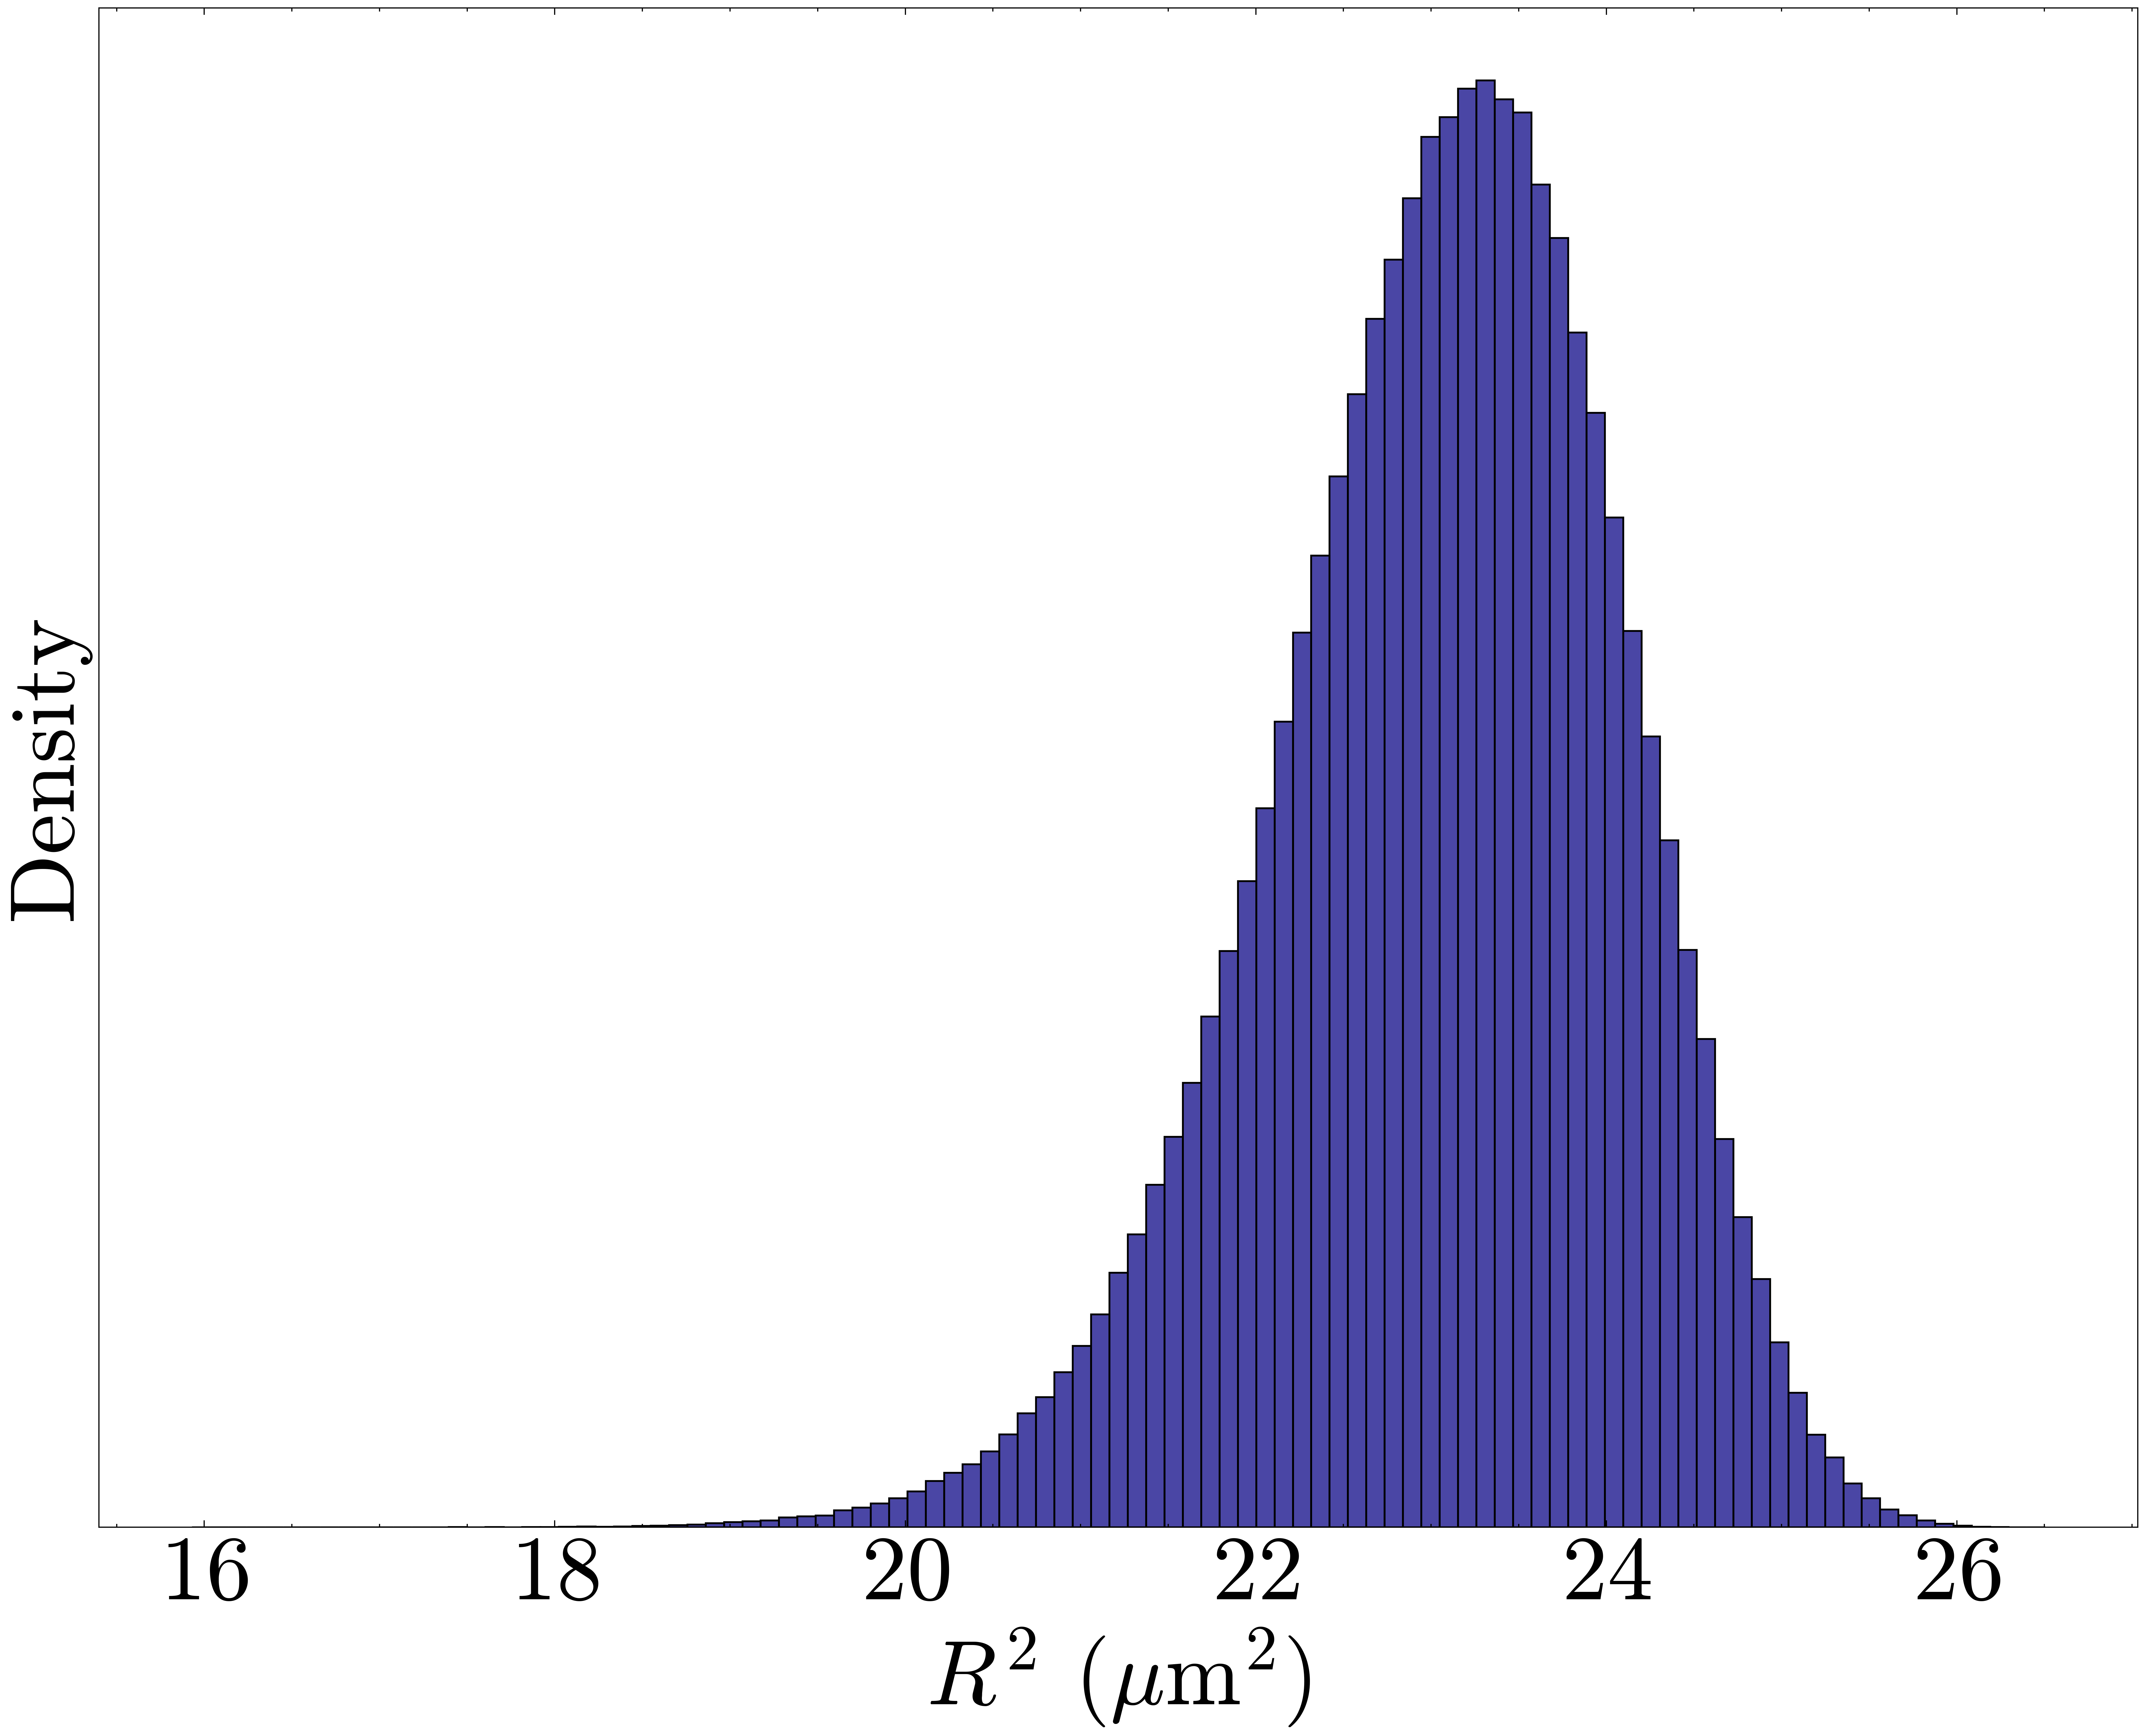

In [101]:
cmap = cm.get_cmap('plasma', 6)  # 3 lines
colors = cmap(np.linspace(0, 1, 6))


try:
    import scienceplots
    plt.style.use(['science', 'ieee', 'no-latex'])  # This avoids the LaTeX dependency
except ImportError:
    print("scienceplots not found. Using default style.")
    plt.style.use('default')
plt.figure(figsize=(16, 12))   
# Adjust font sizes (slightly smaller than before)
plt.rcParams.update({
    'font.size': 40,          # Base font size
    'axes.titlesize': 40,     # Title
    'axes.labelsize': 40,     # Axis labels
    'legend.fontsize': 40,    # Legend
    'xtick.labelsize': 40,    # Tick labels
    'ytick.labelsize': 40
})

# Create the plot

sns.histplot(((10**6)*growth.R), bins=101, color=colors[0], stat='density',edgecolor='black')




plt.legend()
plt.yticks([])
plt.xlabel(r"$R^2$ ($\mu$m$^2$)")
plt.savefig("broadening.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
#divide my domain into stripes 

with open('euler_90.pkl', 'rb') as file:
    s90 = pickle.load(file)
with open('euler_95.pkl', 'rb') as file:
    s95 = pickle.load(file)
with open('euler_100.pkl', 'rb') as file:
    s100 = pickle.load(file)
with open('euler_asw.pkl', 'rb') as file:
    asw = pickle.load(file)
    
with open('growth_90.pkl', 'rb') as file:
    growth90 = pickle.load(file)
with open('growth_95.pkl', 'rb') as file:
    growth95 = pickle.load(file)
with open('growth_100.pkl', 'rb') as file:
    growth100 = pickle.load(file)
with open('growth_asw.pkl', 'rb') as file:
    growthASW = pickle.load(file)





datasets = {
    's90': s90,
    'G90': growth90,
    's95': s95,
    'G95': growth95,
    's100': s100,
    'G100': growth100,
    'asw': asw,
    'Gasw': growthASW
    
}

stripes = {}

for label, dat in datasets.items():
    stripeWidth = 0.01
    yStripes = np.arange(0, H, stripeWidth)

    lisTmean = []
    lisTstd = []
    lisQmean = []
    lisQstd = []
    lisSmean = []
    lisSstd = []
    lisTQcov=[]
    lisTQcorr=[]
    count=0
    for i in np.arange(0, H, stripeWidth):
        count+=1
        particlesConsidered = dat.rectanglesHorizontal(i, i + stripeWidth)
        Tmean = np.mean(particlesConsidered[:, 2])
        Tstd = np.std(particlesConsidered[:, 2])
        Qmean = np.mean(particlesConsidered[:, 3])
        Qstd = np.std(particlesConsidered[:, 3])
        Smean = np.mean(superSat(pr, particlesConsidered[:, 2], particlesConsidered[:, 3]))
        Sstd = np.std(superSat(pr, particlesConsidered[:, 2], particlesConsidered[:, 3]))
        Te=particlesConsidered[:, 2]
        Qu=particlesConsidered[:, 3]
        cov=np.sum((Te - Tmean) * (Qu - Qmean)) / len(Te)
        corr=cov/(Tstd*Qstd)
            
        
        TQcorr=np.corrcoef(particlesConsidered[:, 2], particlesConsidered[:, 3])[0,1]

        lisTmean.append(Tmean)
        lisTstd.append(Tstd)
        lisQmean.append(Qmean)
        lisQstd.append(Qstd)
        lisSmean.append(Smean)
        lisSstd.append(Sstd)
        lisTQcov.append(cov)
        lisTQcorr.append(corr)
        '''if count%10==0:
            plt.figure(figsize=(8, 6))
            plt.scatter(Te,Qu)
            plt.xlim(-dT,dT) 
            plt.title(f"{label}, {count}")
            plt.show()
        '''

    # Save results using labels
    stripes[f'lisTmean{label}'] = np.array(lisTmean)
    stripes[f'lisTstd{label}']  = np.array(lisTstd)
    stripes[f'lisQmean{label}'] = np.array(lisQmean)
    stripes[f'lisQstd{label}']  = np.array(lisQstd)
    stripes[f'lisSmean{label}'] = np.array(lisSmean)
    stripes[f'lisSstd{label}']  = np.array(lisSstd)
    stripes[f'lisTQcorr{label}'] = np.array(lisTQcorr)
    stripes[f"lisTQcov{label}"] = np.array(lisTQcov)

<>:29: SyntaxWarning: invalid escape sequence '\e'
<>:30: SyntaxWarning: invalid escape sequence '\e'
<>:31: SyntaxWarning: invalid escape sequence '\e'
<>:29: SyntaxWarning: invalid escape sequence '\e'
<>:30: SyntaxWarning: invalid escape sequence '\e'
<>:31: SyntaxWarning: invalid escape sequence '\e'
C:\Users\igork\AppData\Local\Temp\ipykernel_34960\2638908244.py:29: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(stripes['lisTQcorrs100'], yStripes, color=colors[0],linestyle='-', linewidth=2, label='$\eta = 1 $')
C:\Users\igork\AppData\Local\Temp\ipykernel_34960\2638908244.py:30: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(stripes['lisTQcorrs95'], yStripes, color=colors[2],linestyle='-', linewidth=2, label='$\eta = 0.95 $')
C:\Users\igork\AppData\Local\Temp\ipykernel_34960\2638908244.py:31: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(stripes['lisTQcorrs90'], yStripes, color=colors[4],linestyle='-', linewidth=2, label='$\eta = 0.90 $')
C:\Users\igork\App

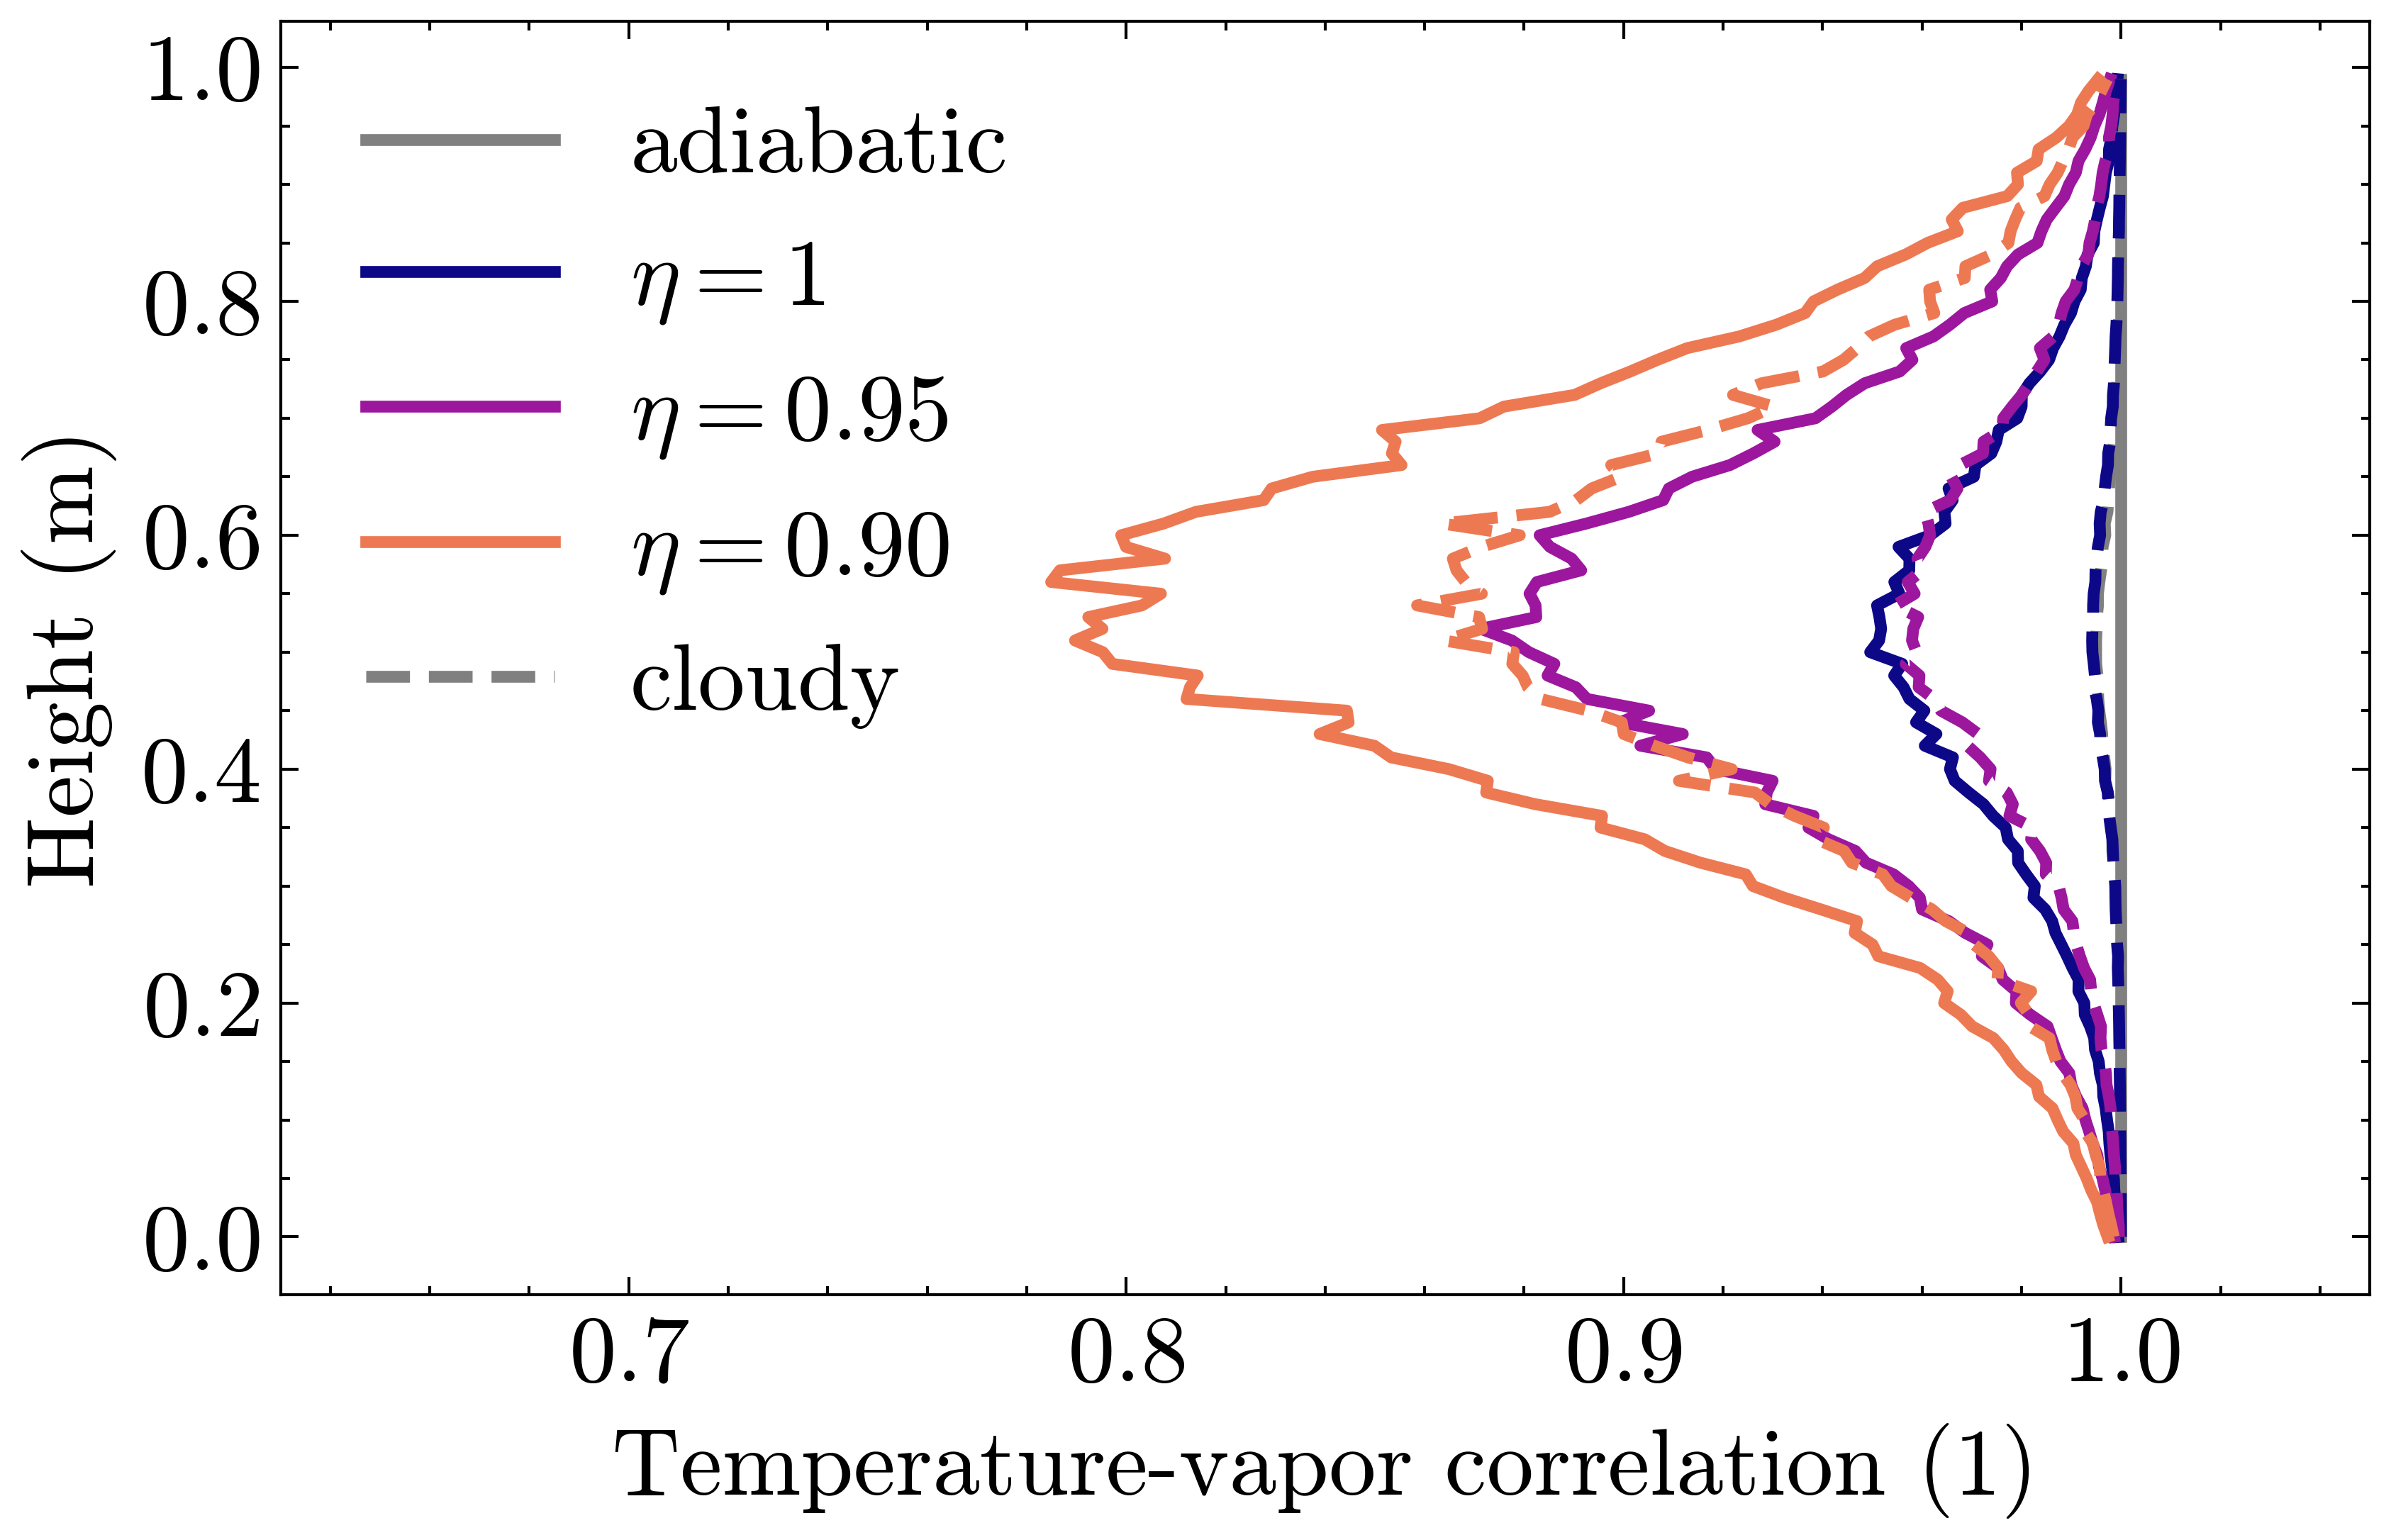

In [9]:
cmap = cm.get_cmap('plasma', 7) 
colors = cmap(np.linspace(0, 1, 7))


try:
    import scienceplots
    plt.style.use(['science', 'ieee', 'no-latex'])  # PRX-style approximation
except ImportError:
    print("scienceplots not found. Using default style.")
    plt.style.use('default')

# Adjust font sizes (slightly smaller than before)
plt.rcParams.update({
    'font.size': 16,          # Base font size
    'axes.titlesize': 16,     # Title
    'axes.labelsize': 16,     # Axis labels
    'legend.fontsize': 16,    # Legend
    'xtick.labelsize': 16,    # Tick labels
    'ytick.labelsize': 16
})



# Create scatter plot
plt.figure(figsize=(6, 4))
plt.xlim(0.63,1.05)

plt.plot(stripes['lisTQcorrasw'], yStripes, color='gray',linestyle='-', linewidth=2, label='adiabatic')
plt.plot(stripes['lisTQcorrs100'], yStripes, color=colors[0],linestyle='-', linewidth=2, label='$\eta = 1 $')
plt.plot(stripes['lisTQcorrs95'], yStripes, color=colors[2],linestyle='-', linewidth=2, label='$\eta = 0.95 $')
plt.plot(stripes['lisTQcorrs90'], yStripes, color=colors[4],linestyle='-', linewidth=2, label='$\eta = 0.90 $')

plt.plot(stripes['lisTQcorrGasw'], yStripes, color='gray',linestyle='--', linewidth=2, label='cloudy')
plt.plot(stripes['lisTQcorrG100'], yStripes, color=colors[0],linestyle='--', linewidth=2)
plt.plot(stripes['lisTQcorrG95'], yStripes, color=colors[2],linestyle='--', linewidth=2)
plt.plot(stripes['lisTQcorrG90'], yStripes, color=colors[4],linestyle='--', linewidth=2)



# Add labels and title
plt.xlabel('Temperature-vapor correlation (1)')
plt.ylabel('Height (m)')
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig("Temperature-vapor_correlation_cloudy")
plt.show()

C:\Users\igork\AppData\Local\Temp\ipykernel_32188\3500331612.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma', 7)


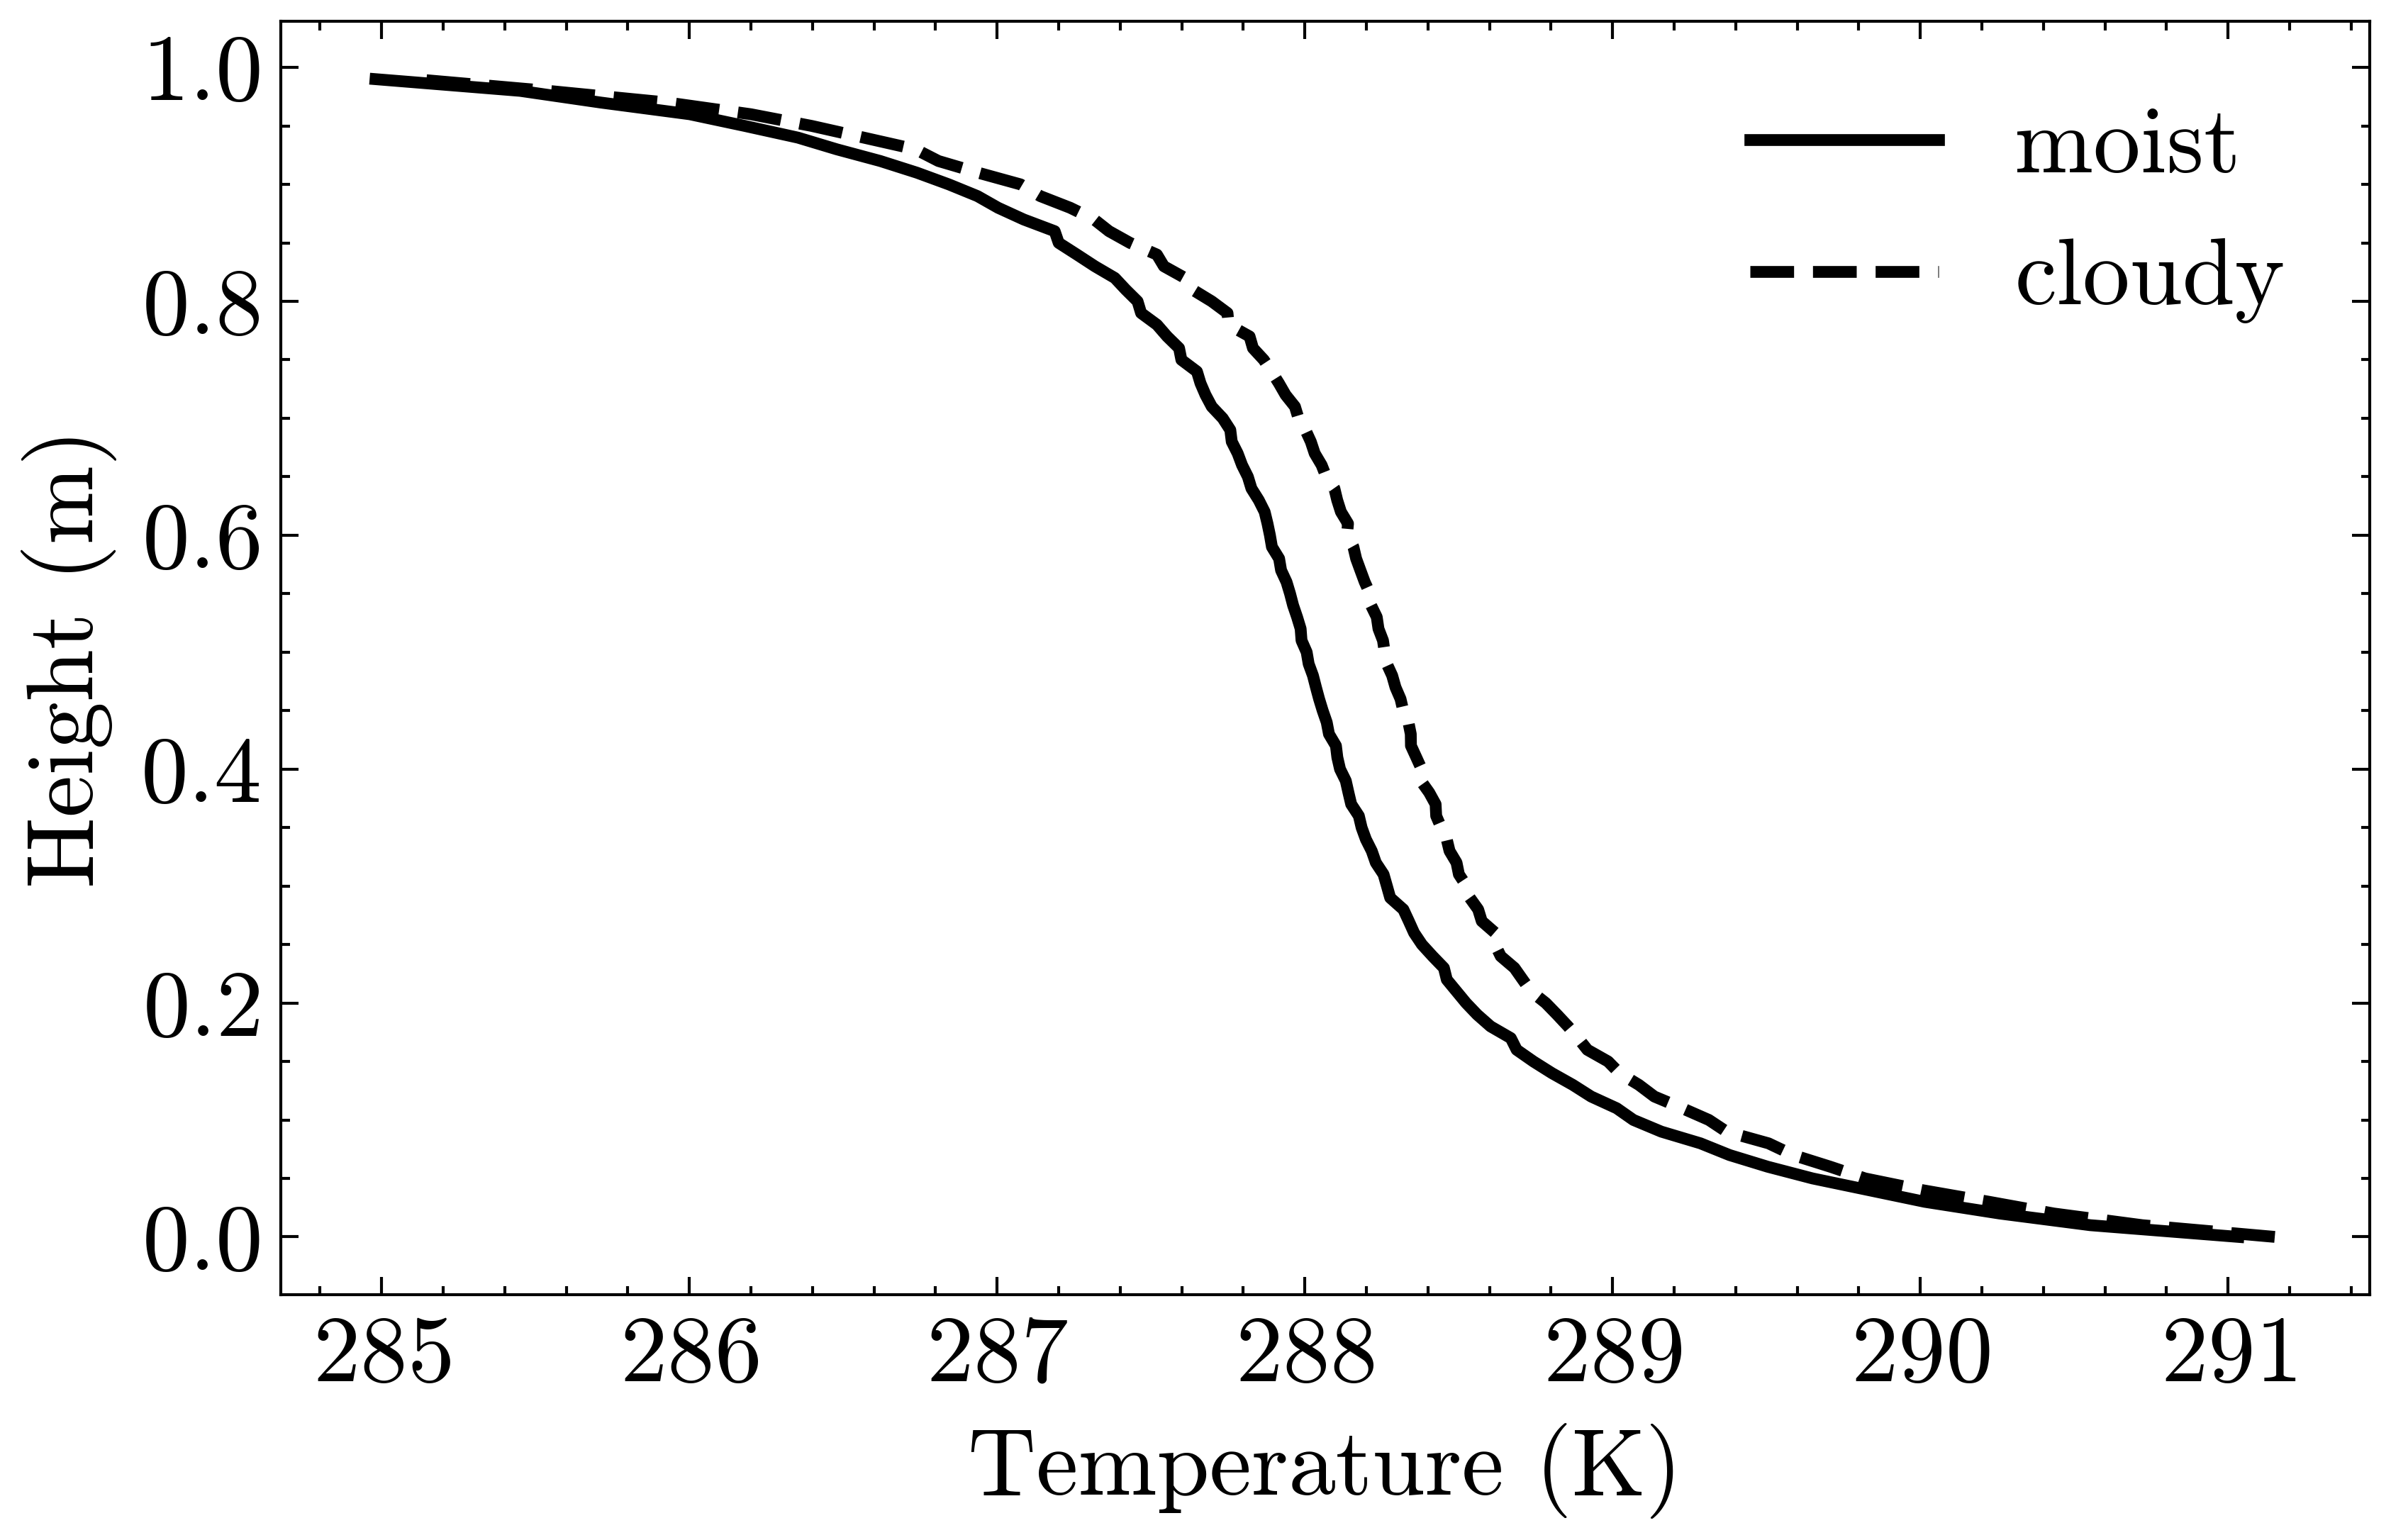

In [39]:
cmap = cm.get_cmap('plasma', 7) 
colors = cmap(np.linspace(0, 1, 7))


try:
    import scienceplots
    plt.style.use(['science', 'ieee', 'no-latex'])  # PRX-style approximation
except ImportError:
    print("scienceplots not found. Using default style.")
    plt.style.use('default')

# Adjust font sizes (slightly smaller than before)
plt.rcParams.update({
    'font.size': 16,          # Base font size
    'axes.titlesize': 16,     # Title
    'axes.labelsize': 16,     # Axis labels
    'legend.fontsize': 16,    # Legend
    'xtick.labelsize': 16,    # Tick labels
    'ytick.labelsize': 16
})



# Create scatter plot
plt.figure(figsize=(6, 4))


plt.plot(stripes['lisTmeanasw'], yStripes, color='black',linestyle='-', linewidth=2, label='moist')
plt.plot(stripes['lisTmeanGasw'], yStripes, color='black',linestyle='--', linewidth=2, label='cloudy')





# Add labels and title
plt.xlabel('Temperature (K)')
plt.ylabel('Height (m)')
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("Temperature_mean_cloudy")
plt.show()

C:\Users\igork\AppData\Local\Temp\ipykernel_32188\4204417074.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma', 7)


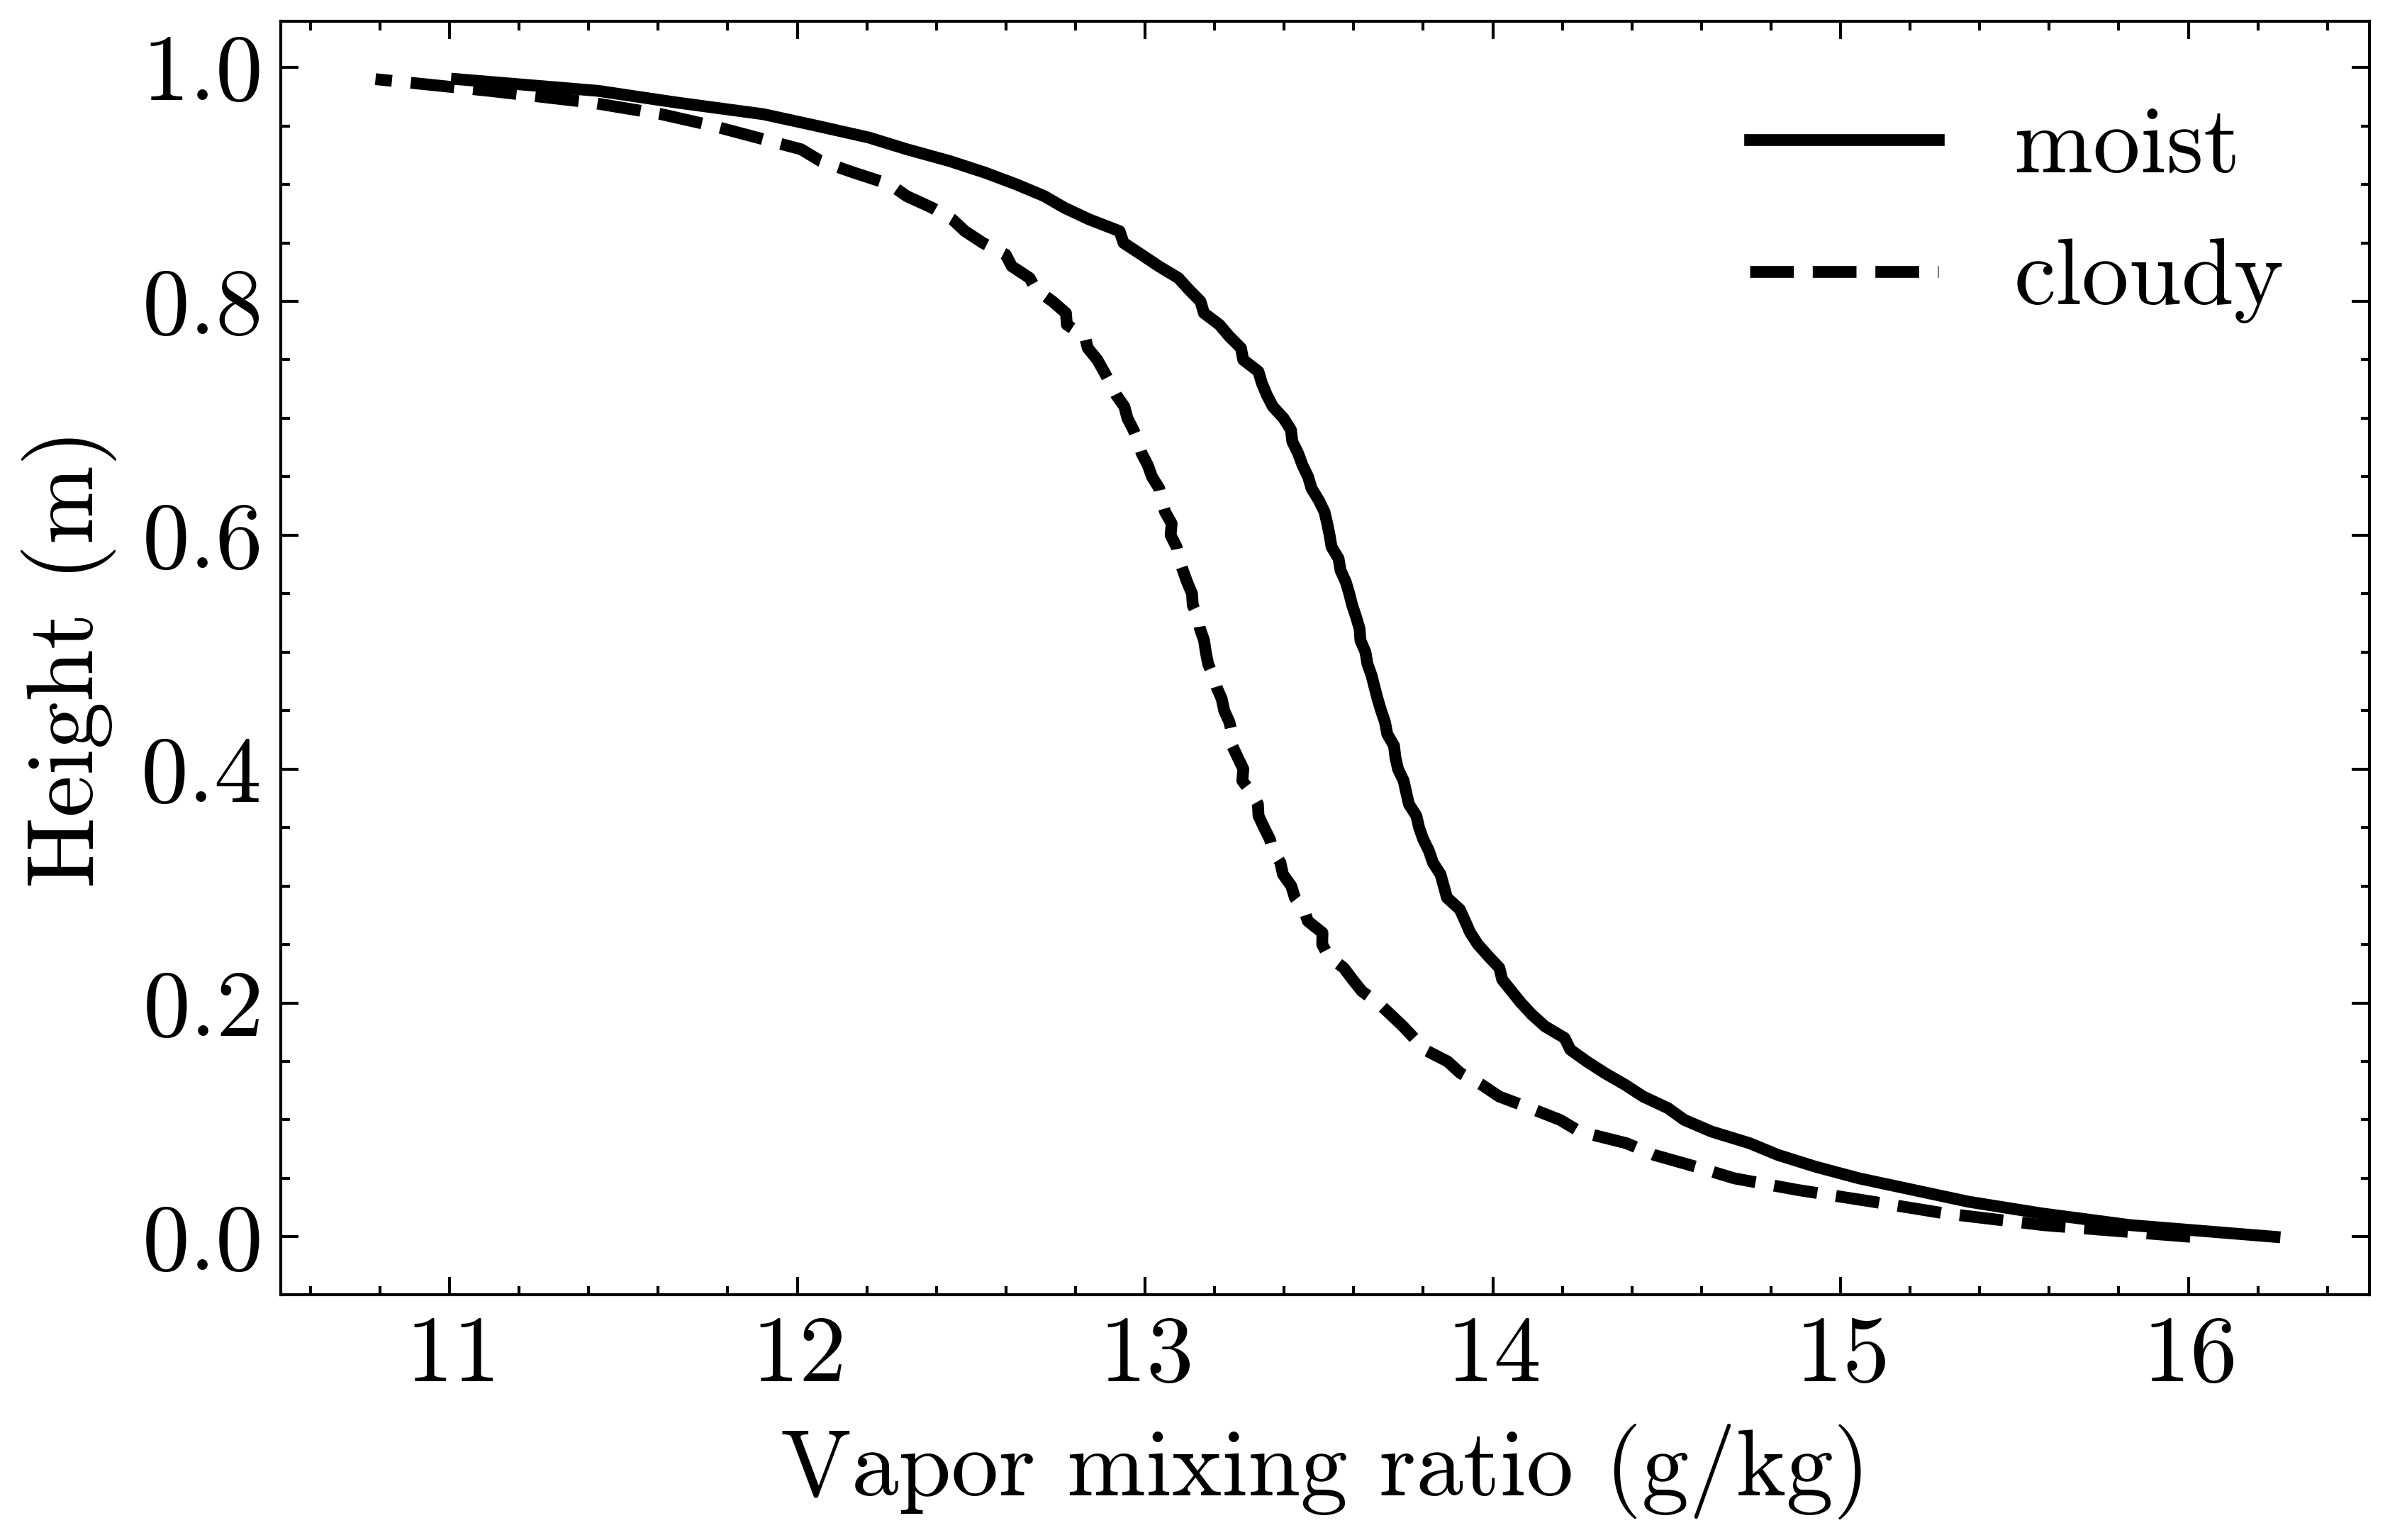

In [37]:
cmap = cm.get_cmap('plasma', 7) 
colors = cmap(np.linspace(0, 1, 7))


try:
    import scienceplots
    plt.style.use(['science', 'ieee', 'no-latex'])  # PRX-style approximation
except ImportError:
    print("scienceplots not found. Using default style.")
    plt.style.use('default')

# Adjust font sizes (slightly smaller than before)
plt.rcParams.update({
    'font.size': 16,          # Base font size
    'axes.titlesize': 16,     # Title
    'axes.labelsize': 16,     # Axis labels
    'legend.fontsize': 16,    # Legend
    'xtick.labelsize': 16,    # Tick labels
    'ytick.labelsize': 16
})



# Create scatter plot
plt.figure(figsize=(6, 4))


plt.plot(1000*stripes['lisQmeanasw'], yStripes, color='black',linestyle='-', linewidth=2, label='moist')
plt.plot(1000*stripes['lisQmeanGasw'], yStripes, color='black',linestyle='--', linewidth=2, label='cloudy')





# Add labels and title
plt.xlabel('Vapor mixing ratio (g/kg)')
plt.ylabel('Height (m)')
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("Vapor_mean_cloudy")
plt.show()

C:\Users\igork\AppData\Local\Temp\ipykernel_32332\1346473741.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma', 6)


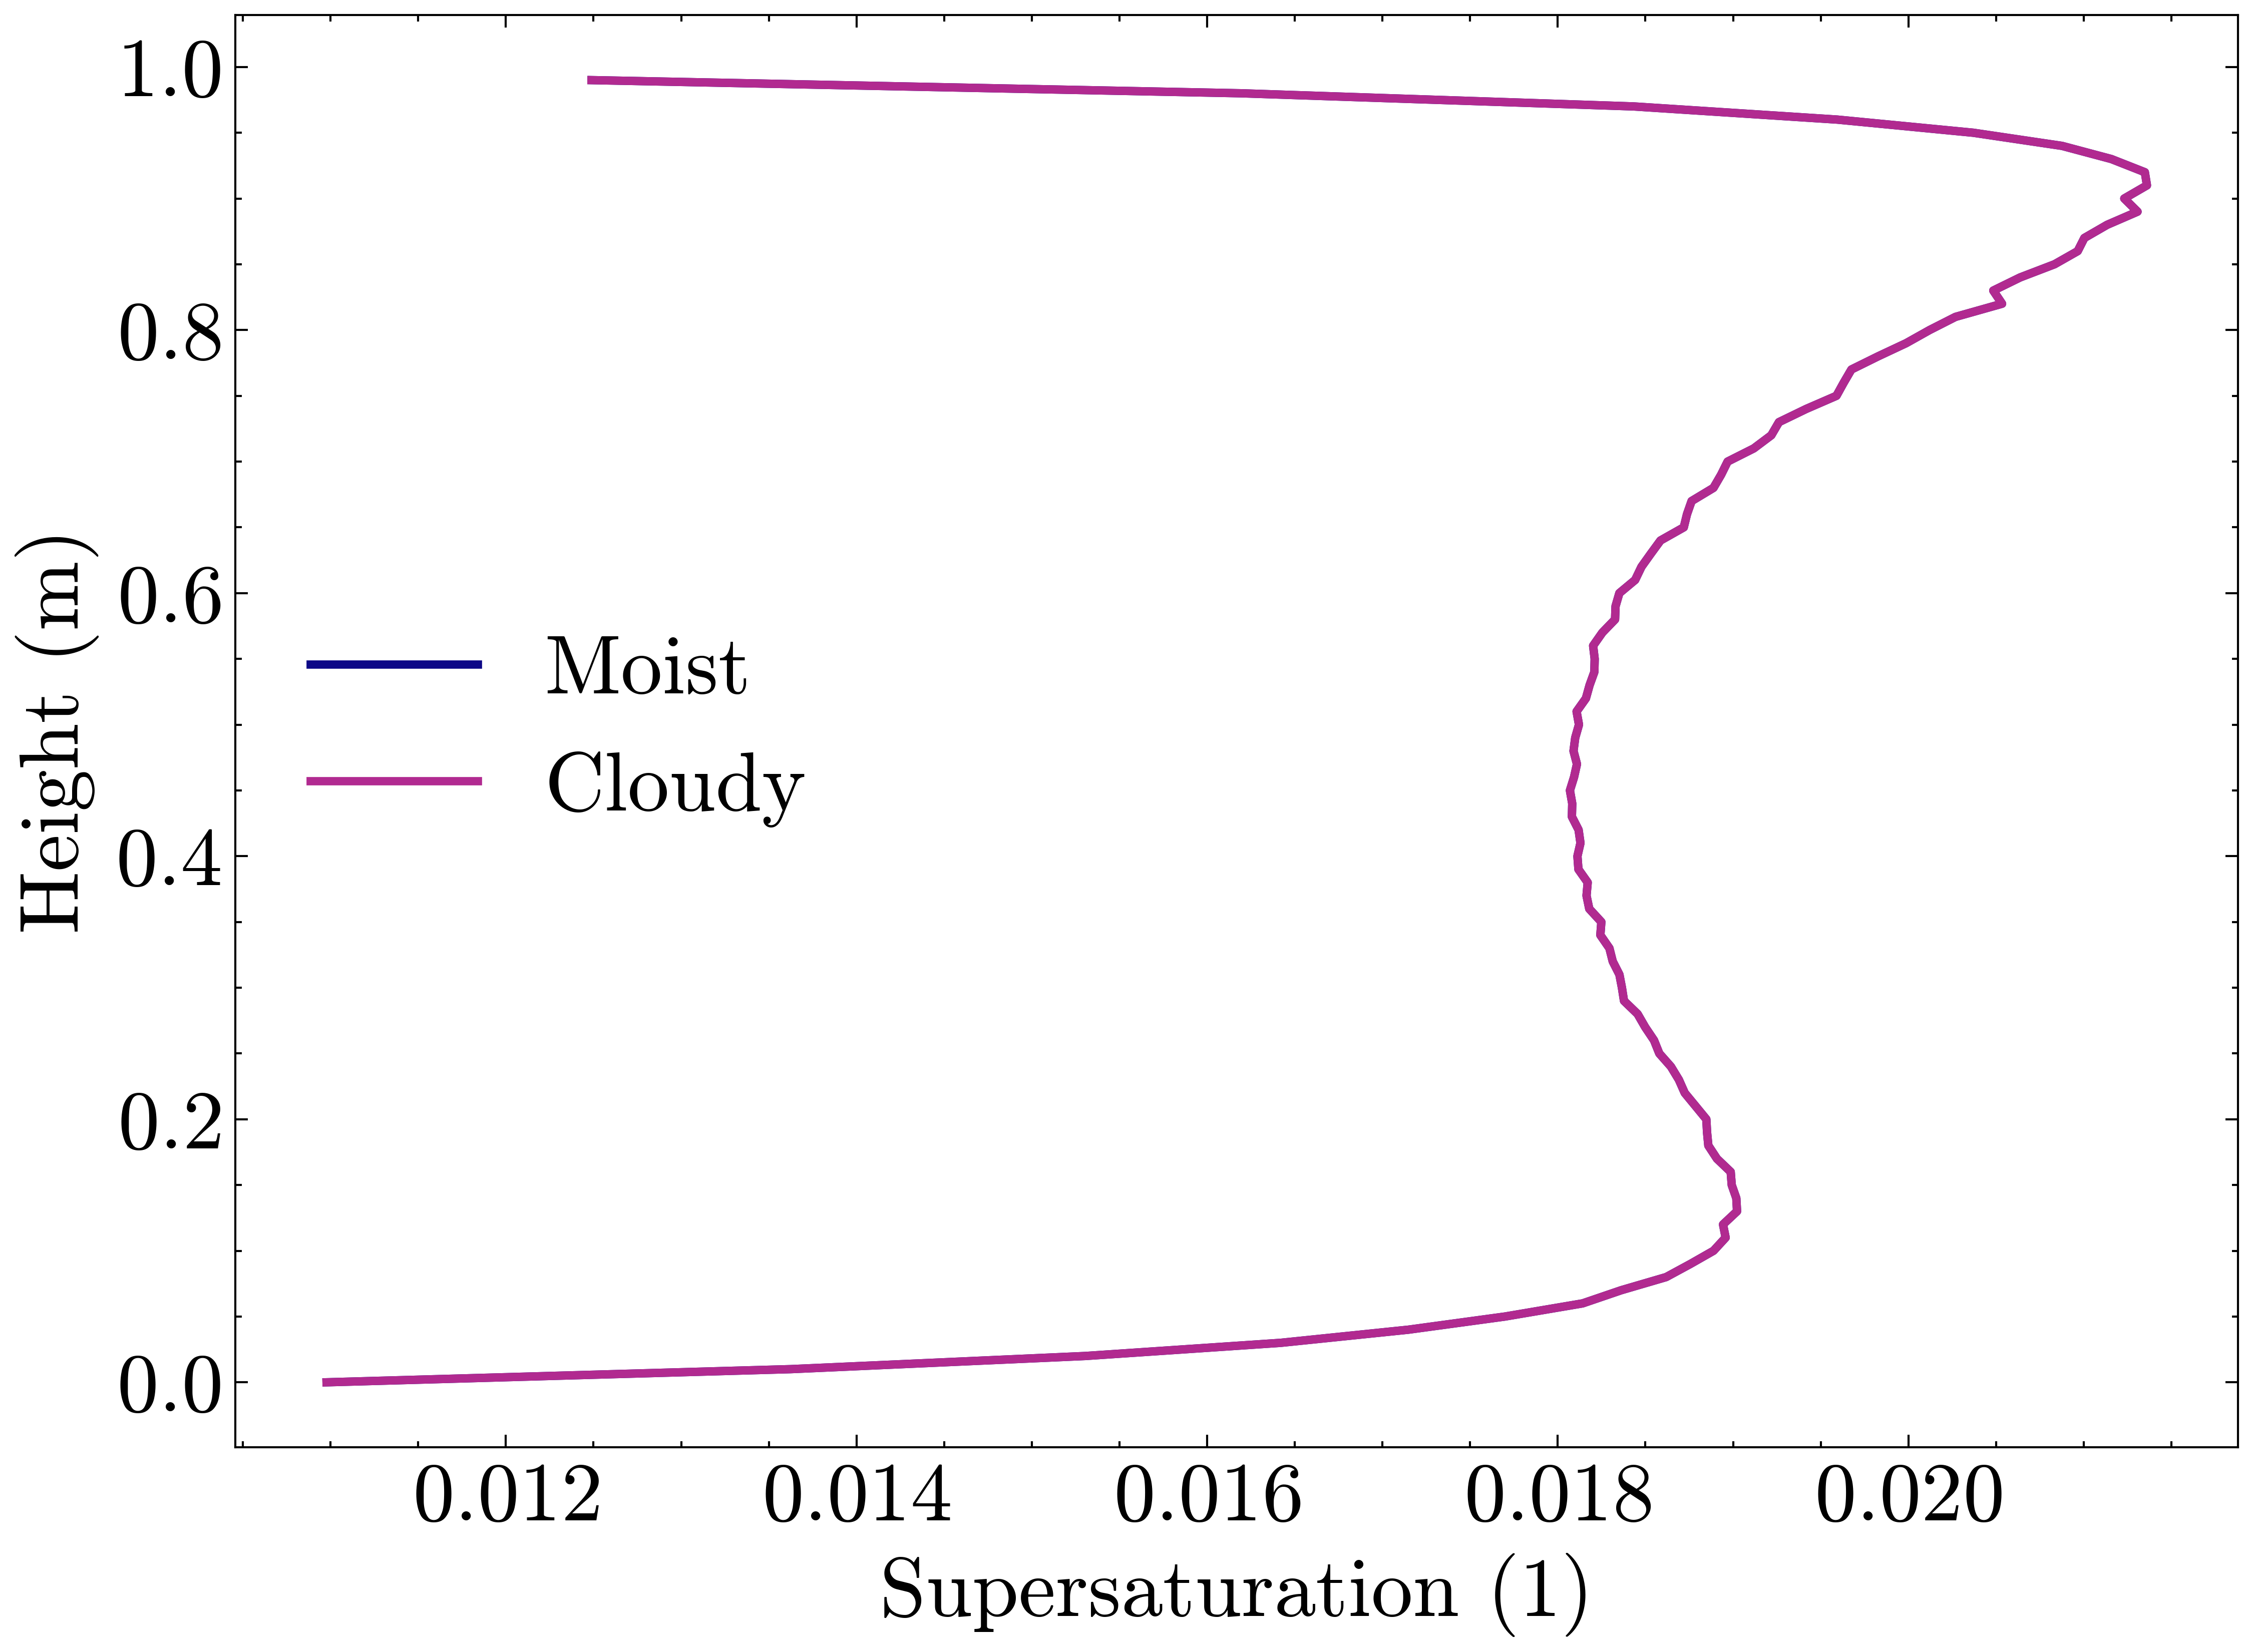

In [16]:
cmap = cm.get_cmap('plasma', 6) 
colors = cmap(np.linspace(0, 1, 6))


try:
    import scienceplots
    plt.style.use(['science', 'ieee', 'no-latex'])  # PRX-style approximation
except ImportError:
    print("scienceplots not found. Using default style.")
    plt.style.use('default')

# Adjust font sizes (slightly smaller than before)
plt.rcParams.update({
    'font.size': 20,          # Base font size
    'axes.titlesize': 20,     # Title
    'axes.labelsize': 20,     # Axis labels
    'legend.fontsize': 20,    # Legend
    'xtick.labelsize': 20,    # Tick labels
    'ytick.labelsize': 20
})



# Create scatter plot
plt.figure(figsize=(8, 6))


plt.plot(stripes['lisSmeanASW'], yStripes, color=colors[0],linestyle='-', linewidth=2, label='Moist')
plt.plot(stripes['lisSmeanGrowth'], yStripes, color=colors[2], linestyle='-', linewidth=2,label='Cloudy')


# Add labels and title
plt.xlabel('Supersaturation (1)')
plt.ylabel('Height (m)')
plt.legend(loc="center left")
plt.tight_layout()
plt.savefig("S_growth.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\igork\AppData\Local\Temp\ipykernel_32332\3282251221.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma', 6)


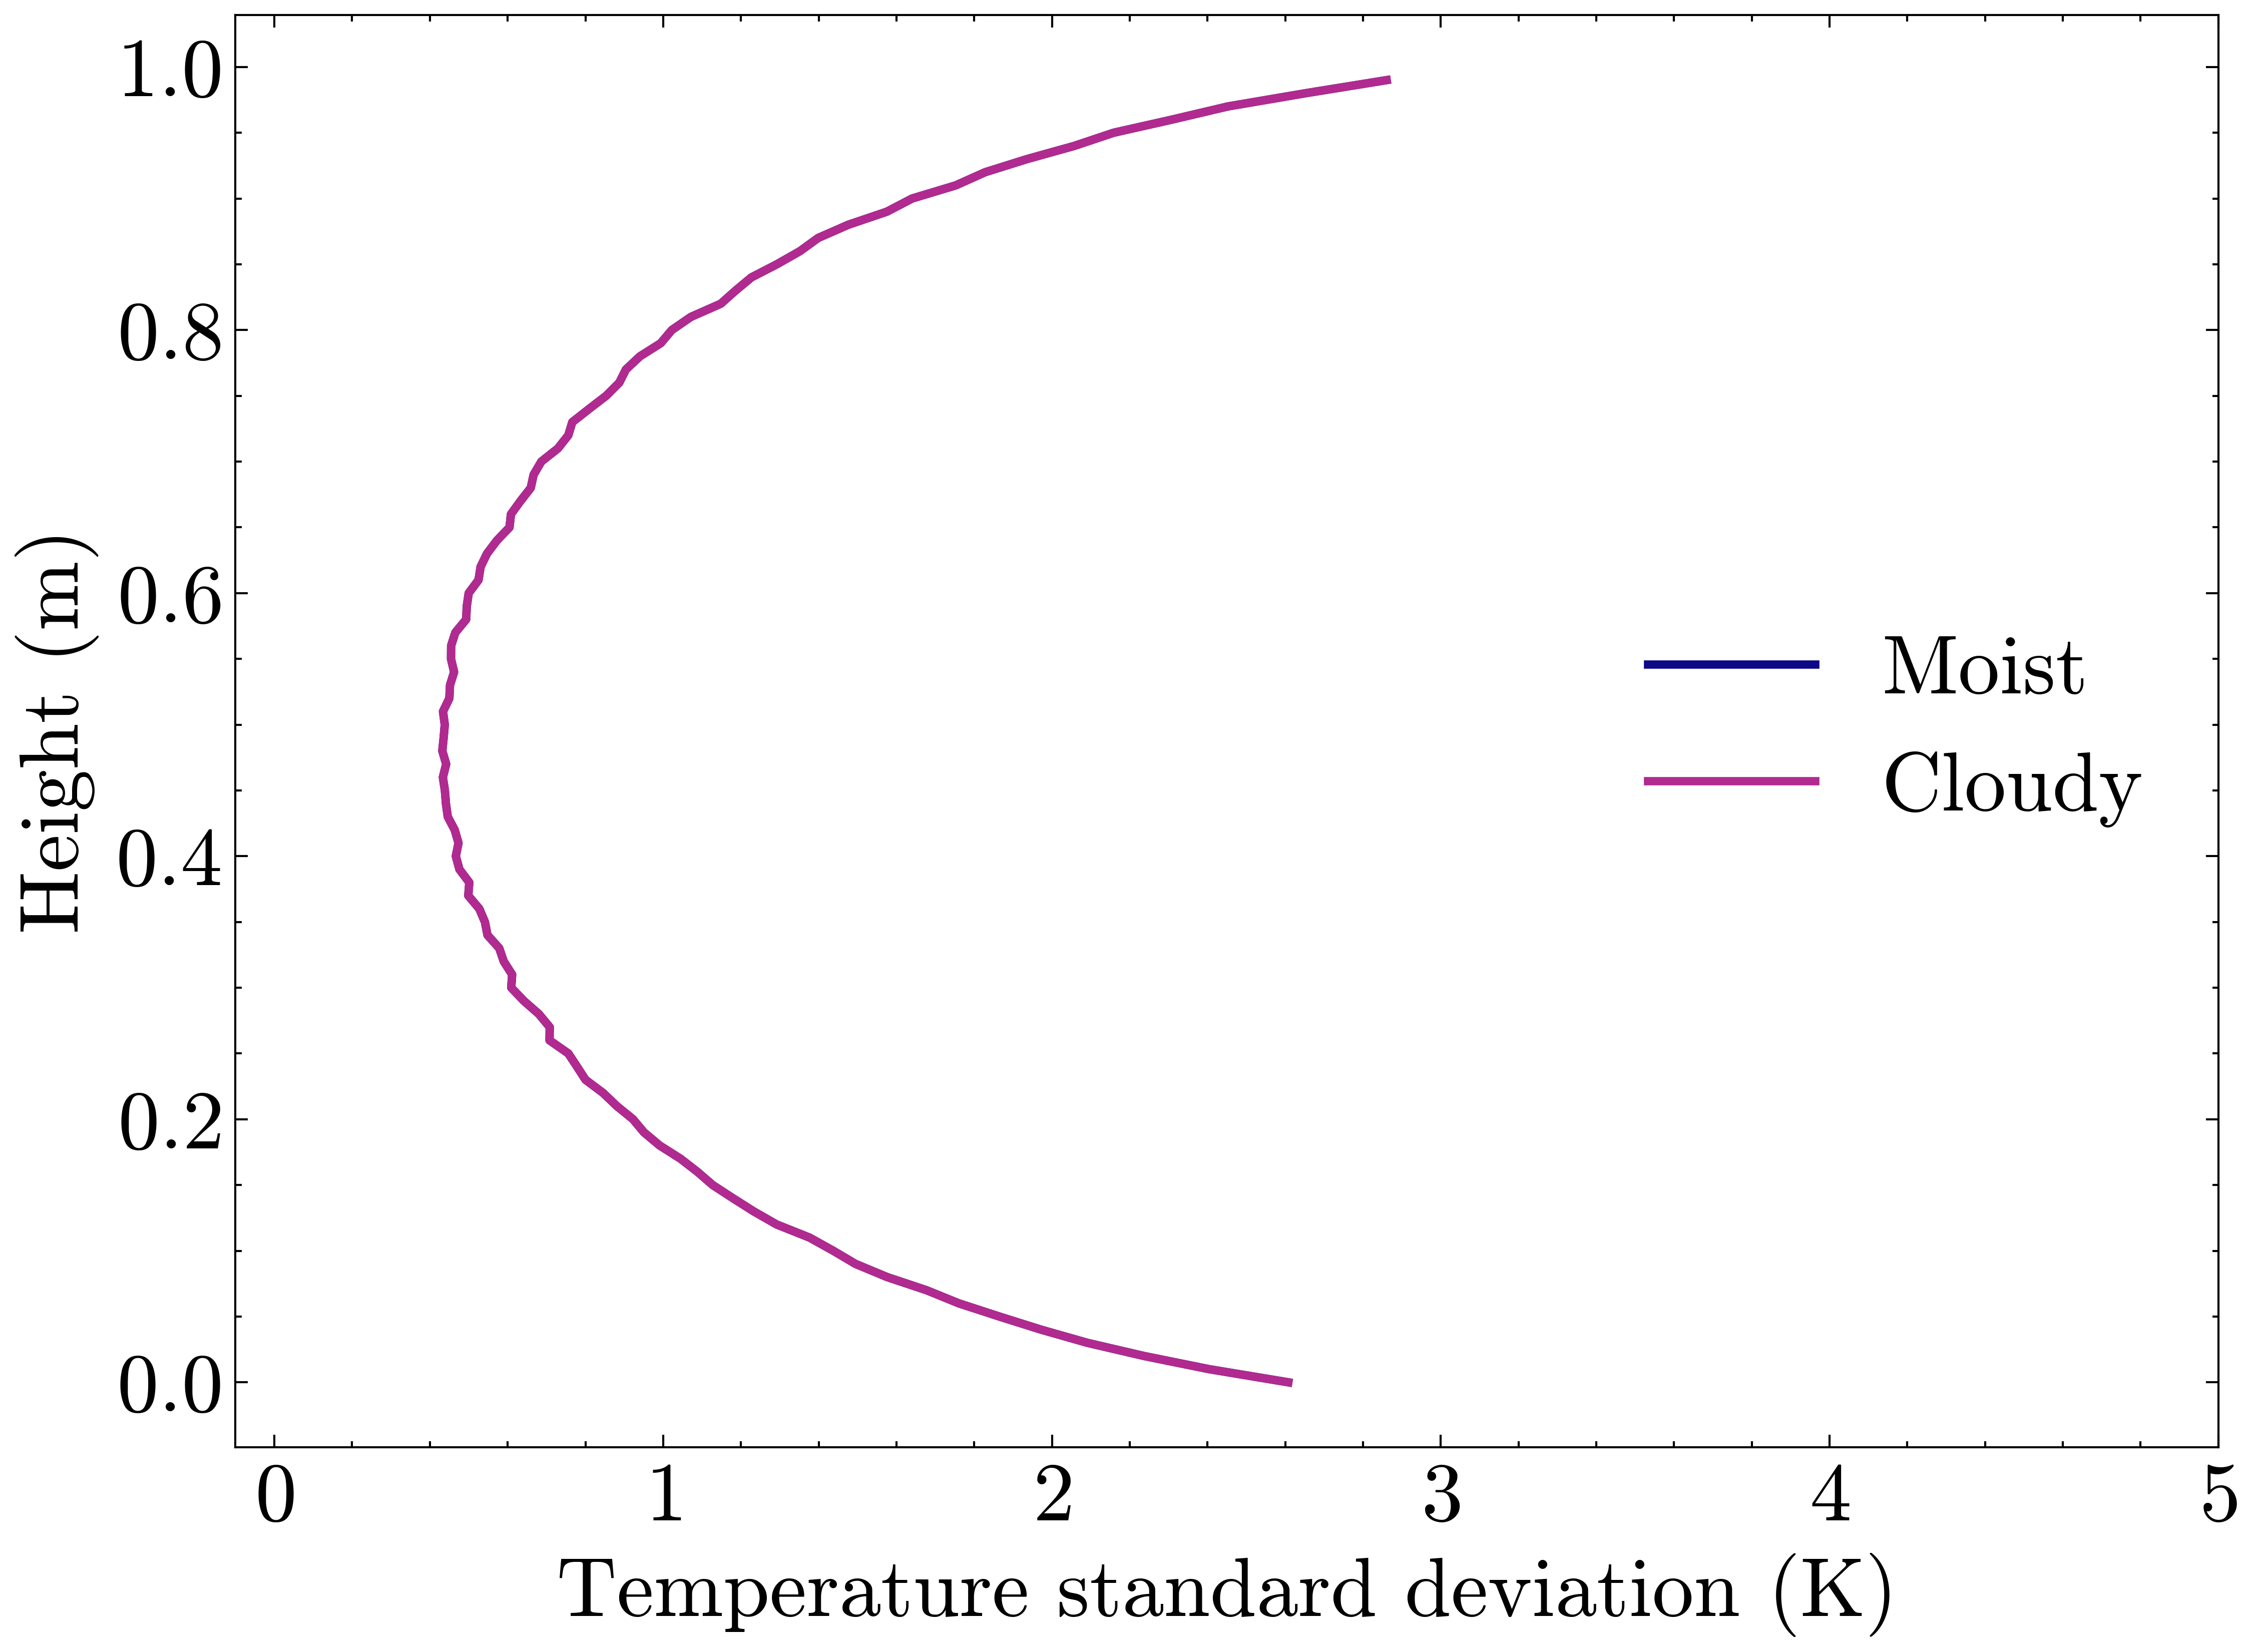

In [17]:
cmap = cm.get_cmap('plasma', 6) 
colors = cmap(np.linspace(0, 1, 6))


try:
    import scienceplots
    plt.style.use(['science', 'ieee', 'no-latex'])  # PRX-style approximation
except ImportError:
    print("scienceplots not found. Using default style.")
    plt.style.use('default')

# Adjust font sizes (slightly smaller than before)
plt.rcParams.update({
    'font.size': 20,          # Base font size
    'axes.titlesize': 20,     # Title
    'axes.labelsize': 20,     # Axis labels
    'legend.fontsize': 20,    # Legend
    'xtick.labelsize': 20,    # Tick labels
    'ytick.labelsize': 20
})



# Create scatter plot
plt.figure(figsize=(8, 6))


plt.plot(stripes['lisTstdASW'], yStripes, color=colors[0],linestyle='-', linewidth=2, label='Moist')
plt.plot(stripes['lisTstdGrowth'], yStripes, color=colors[2], linestyle='-', linewidth=2,label='Cloudy')


# Add labels and title
plt.xlabel('Temperature standard deviation (K)')
plt.xlim(-0.1,5)
plt.ylabel('Height (m)')
plt.legend(loc="center right")
plt.tight_layout()
plt.savefig("Temp_std_growth.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\igork\AppData\Local\Temp\ipykernel_10520\785416153.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma', 6)


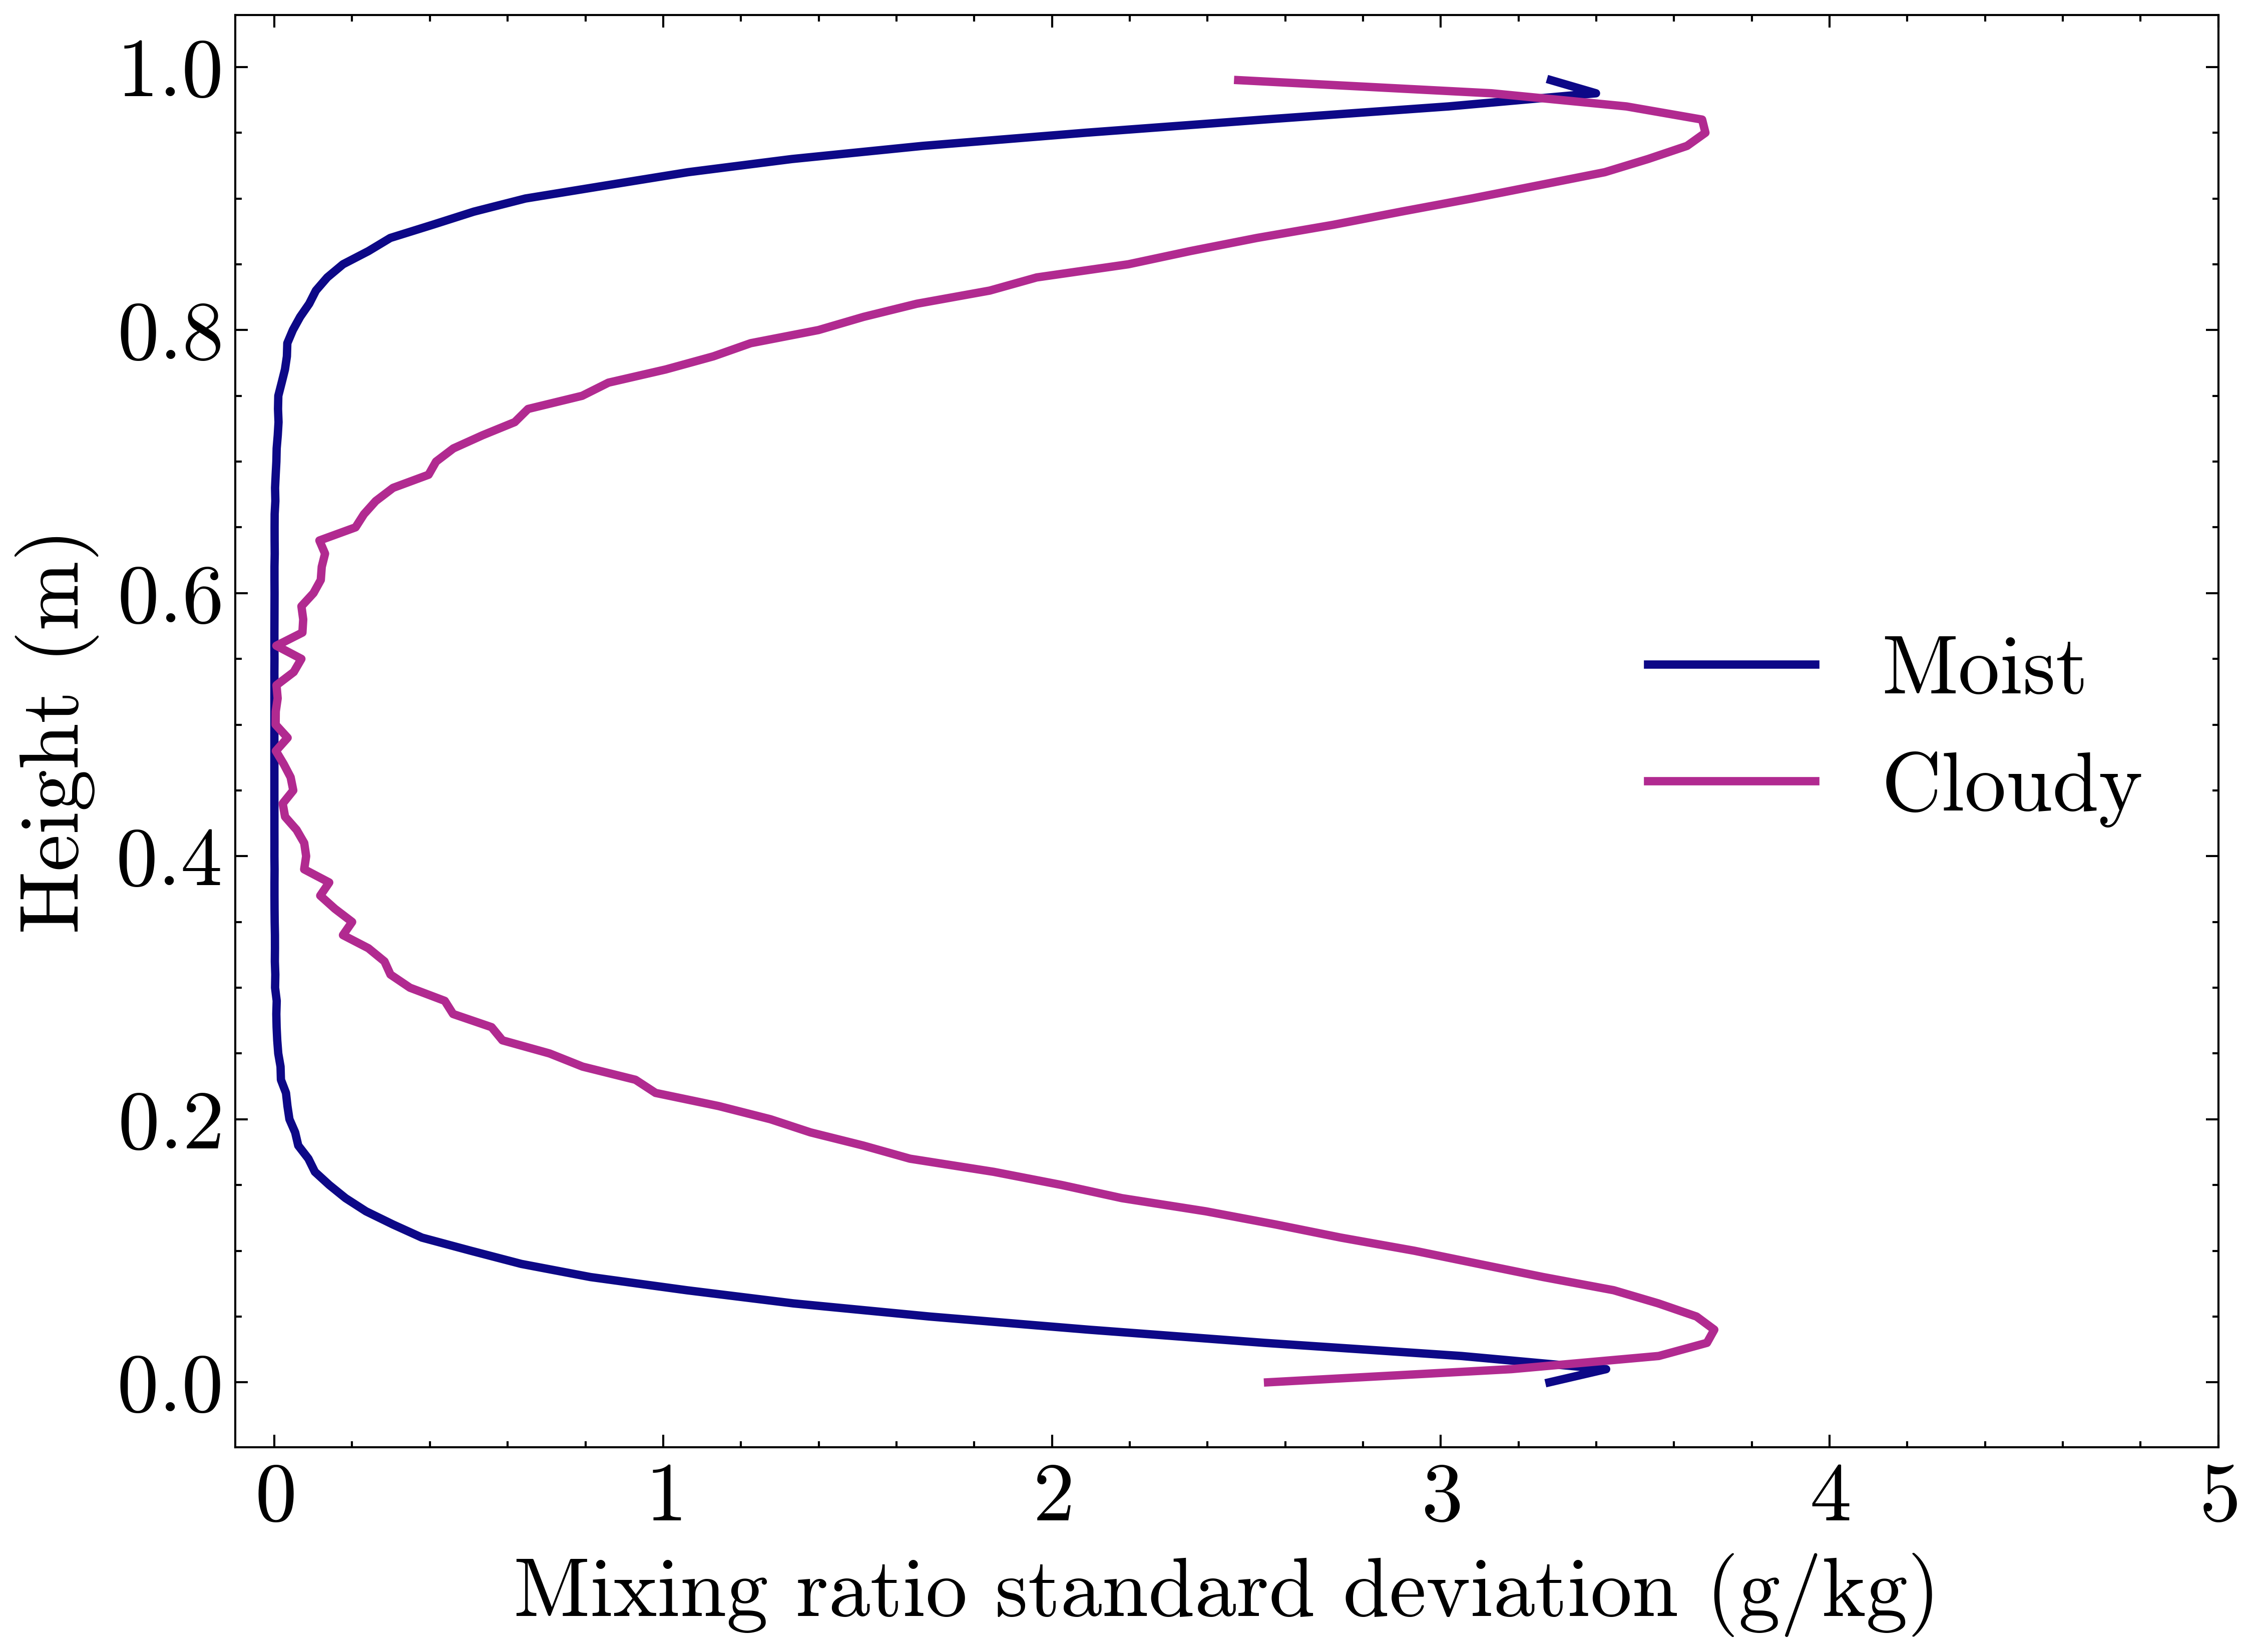

In [19]:
cmap = cm.get_cmap('plasma', 6) 
colors = cmap(np.linspace(0, 1, 6))


try:
    import scienceplots
    plt.style.use(['science', 'ieee', 'no-latex'])  # PRX-style approximation
except ImportError:
    print("scienceplots not found. Using default style.")
    plt.style.use('default')

# Adjust font sizes (slightly smaller than before)
plt.rcParams.update({
    'font.size': 20,          # Base font size
    'axes.titlesize': 20,     # Title
    'axes.labelsize': 20,     # Axis labels
    'legend.fontsize': 20,    # Legend
    'xtick.labelsize': 20,    # Tick labels
    'ytick.labelsize': 20
})



# Create scatter plot
plt.figure(figsize=(8, 6))


plt.plot(1000*stripes['lisQstdASW'], yStripes, color=colors[0],linestyle='-', linewidth=2, label='Moist')
plt.plot(1000*stripes['lisQstdGrowth'], yStripes, color=colors[2], linestyle='-', linewidth=2,label='Cloudy')


# Add labels and title
plt.xlabel('Mixing ratio standard deviation (g/kg)')
plt.xlim(-.1,5)
plt.ylabel('Height (m)')
plt.legend(loc="center right")
plt.tight_layout()
plt.savefig("Q_std_growth.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\igork\AppData\Local\Temp\ipykernel_10520\2077644045.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma', 6)


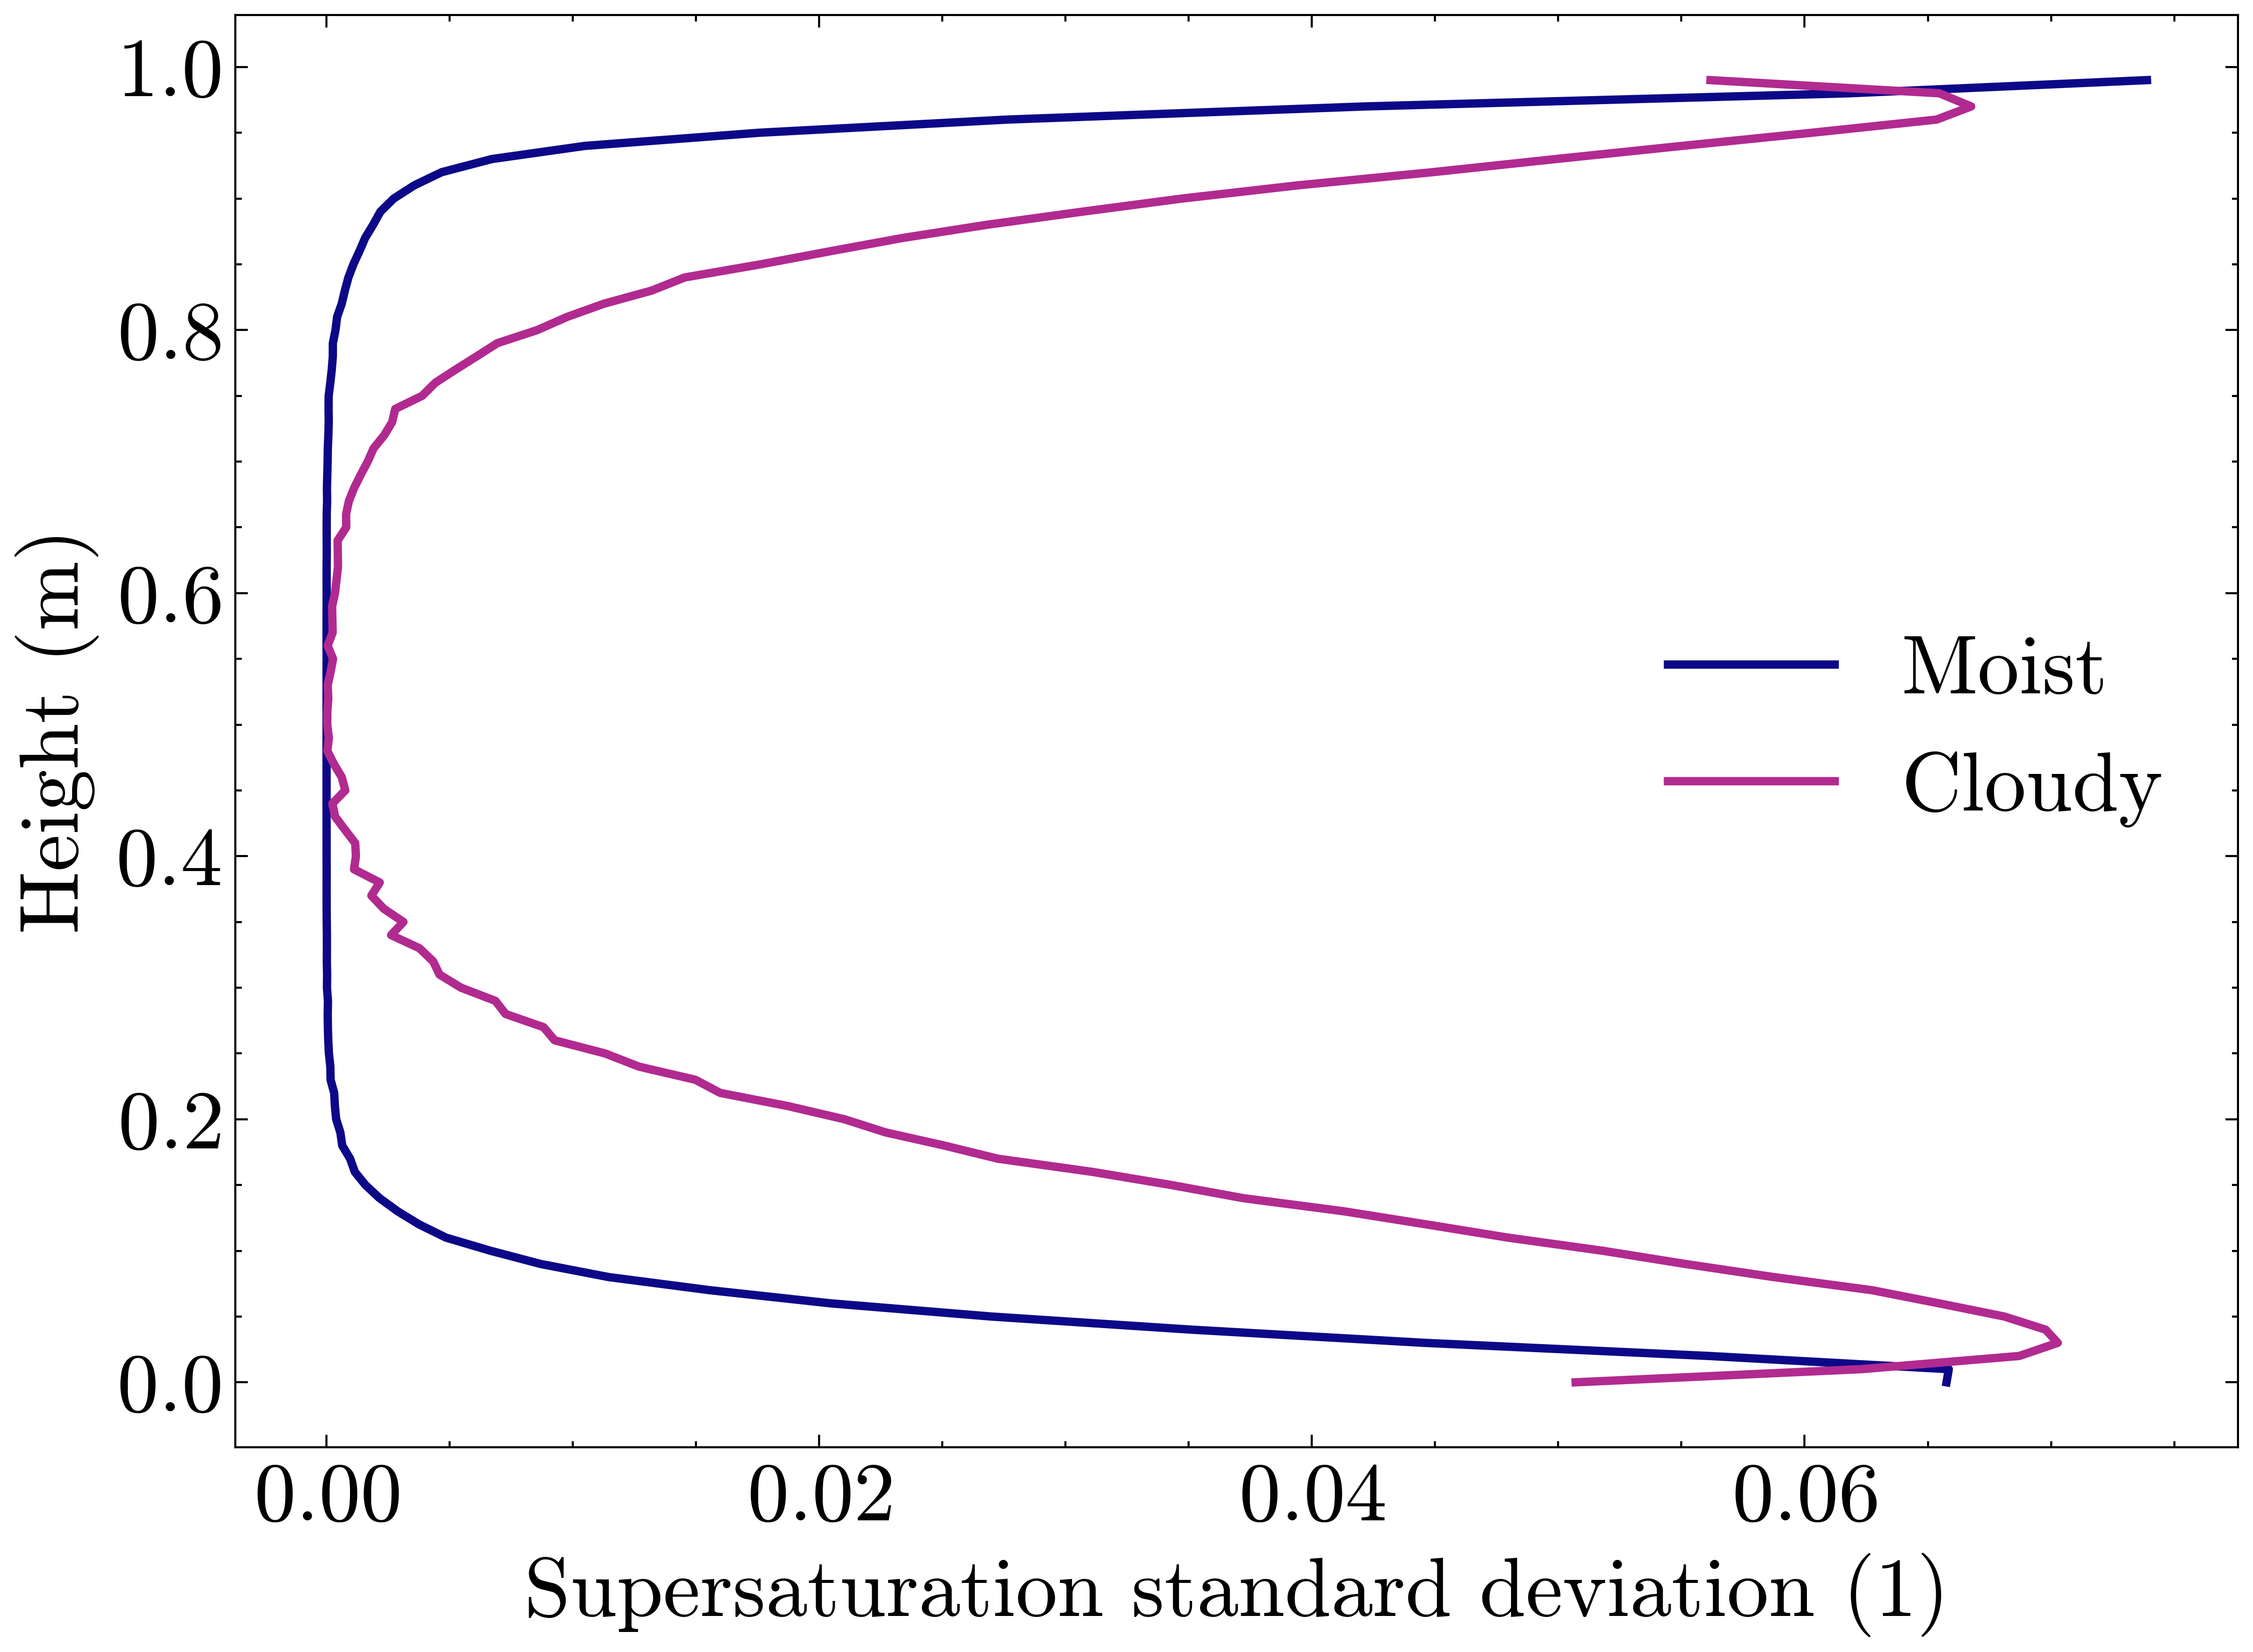

In [20]:
cmap = cm.get_cmap('plasma', 6) 
colors = cmap(np.linspace(0, 1, 6))


try:
    import scienceplots
    plt.style.use(['science', 'ieee', 'no-latex'])  # PRX-style approximation
except ImportError:
    print("scienceplots not found. Using default style.")
    plt.style.use('default')

# Adjust font sizes (slightly smaller than before)
plt.rcParams.update({
    'font.size': 20,          # Base font size
    'axes.titlesize': 20,     # Title
    'axes.labelsize': 20,     # Axis labels
    'legend.fontsize': 20,    # Legend
    'xtick.labelsize': 20,    # Tick labels
    'ytick.labelsize': 20
})



# Create scatter plot
plt.figure(figsize=(8, 6))


plt.plot(stripes['lisSstdASW'], yStripes, color=colors[0],linestyle='-', linewidth=2, label='Moist')
plt.plot(stripes['lisSstdGrowth'], yStripes, color=colors[2], linestyle='-', linewidth=2,label='Cloudy')


# Add labels and title
plt.xlabel('Supersaturation standard deviation (1)')
plt.ylabel('Height (m)')
plt.legend(loc="center right")
plt.tight_layout()
plt.savefig("S_std_growth.png", dpi=300, bbox_inches='tight')
plt.show()

In [21]:
np.mean(stoch.R)

np.float64(2.0041242040913032e-05)

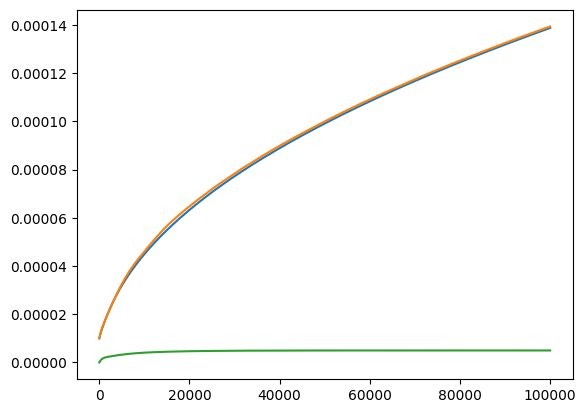

In [56]:
plt.plot(np.arange(0,len(stata[0])),stata[0])
plt.plot(np.arange(0,len(stata[0])),stata[1])
plt.plot(np.arange(0,len(stata[0])),stata[2])

In [29]:
np.isnan(stoch.R).sum()

np.int64(0)

In [41]:
print(np.sqrt(2*(2/3)*tau*k)*np.sqrt(dt),np.mean(stoch.v[:,0])*dt)
print((2/3)*tau*k)

0.09200874124564723 6.875710281945072e-08
0.04232804232804233


c:\Users\igork\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\axes\_axes.py:7065: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
c:\Users\igork\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\axes\_axes.py:7066: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


ValueError: autodetected range of [nan, nan] is not finite

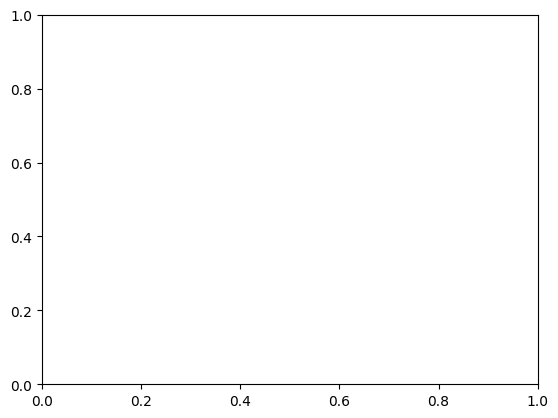

In [49]:
plt.hist((10**6)*(stoch.R)**2,bins=101)
plt.show()

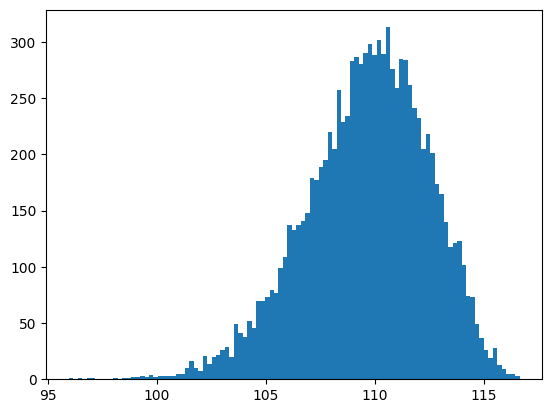

In [63]:
plt.hist((10**6)*(particlesR.R),bins=101)
plt.show()

In [ ]:
with open('20250608_1000000_aswNoG_300_10_10_0001_280_19.pkl', 'rb') as file:
    asw = pickle.load(file)
with open('20250701_1000000_s100NoG_300_10_10_0001_280_19.pkl', 'rb') as file:
    s100 = pickle.load(file)
with open('20250701_1000000_s95NoG_300_10_10_0001_280_19.pkl', 'rb') as file:
    s95 = pickle.load(file)

In [67]:
#divide my domain into stripes 
datasets = {
    'R': particlesR

    
}

stripes = {}

for label, dat in datasets.items():
    stripeWidth = 0.01
    yStripes = np.arange(0, H, stripeWidth)

    lisTmean = []
    lisTstd = []
    lisQmean = []
    lisQstd = []
    lisSmean = []
    lisSstd = []
    lisTQcorr=[]

    for i in np.arange(0, H, stripeWidth):
        particlesConsidered = dat.rectanglesHorizontal(i, i + stripeWidth)
        Tmean = np.mean(particlesConsidered[:, 2])
        Tstd = np.std(particlesConsidered[:, 2])
        Qmean = np.mean(particlesConsidered[:, 3])
        Qstd = np.std(particlesConsidered[:, 3])
        Smean = np.mean(superSat(pr, particlesConsidered[:, 2], particlesConsidered[:, 3]))
        Sstd = np.std(superSat(pr, particlesConsidered[:, 2], particlesConsidered[:, 3]))
        TQcorr=np.corrcoef(particlesConsidered[:, 2], particlesConsidered[:, 3])[0,1]

        lisTmean.append(Tmean)
        lisTstd.append(Tstd)
        lisQmean.append(Qmean)
        lisQstd.append(Qstd)
        lisSmean.append(Smean)
        lisSstd.append(Sstd)
        lisTQcorr.append(TQcorr)

    # Save results using labels
    stripes[f'lisTmean{label}'] = np.array(lisTmean)
    stripes[f'lisTstd{label}']  = np.array(lisTstd)
    stripes[f'lisQmean{label}'] = np.array(lisQmean)
    stripes[f'lisQstd{label}']  = np.array(lisQstd)
    stripes[f'lisSmean{label}'] = np.array(lisSmean)
    stripes[f'lisSstd{label}']  = np.array(lisSstd)
    stripes[f'lisTQcorr{label}'] = np.array(lisTQcorr)

In [22]:
cmap = cm.get_cmap('plasma', 6) 
colors = cmap(np.linspace(0, 1, 6))


try:
    import scienceplots
    plt.style.use(['science', 'ieee', 'no-latex'])  # PRX-style approximation
except ImportError:
    print("scienceplots not found. Using default style.")
    plt.style.use('default')

# Adjust font sizes (slightly smaller than before)
plt.rcParams.update({
    'font.size': 20,          # Base font size
    'axes.titlesize': 20,     # Title
    'axes.labelsize': 20,     # Axis labels
    'legend.fontsize': 20,    # Legend
    'xtick.labelsize': 20,    # Tick labels
    'ytick.labelsize': 20
})



# Create scatter plot
plt.figure(figsize=(8, 6))


plt.plot(stripes['lisSstdR'], yStripes, color=colors[0],linestyle='-', linewidth=2, label='ASW')


# Add labels and title
plt.xlabel('Temperature (K)')
plt.ylabel('Height (m)')
plt.legend(loc="center right")
plt.tight_layout()
plt.savefig("Temp_sw.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\igork\AppData\Local\Temp\ipykernel_10520\1589476983.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma', 6)


KeyError: 'lisSstdR'

<Figure size 4800x3600 with 0 Axes>

In [7]:
def f1(par):
    par=par+1
def f2(par):
    par=par+"1"
def f3(par):
    par=par+[1]
    
u1,u2,u3=0,"0",[0]
f1(u1)
f2(u2)
f3(u3)
print(u1)
print(u2)
print(u3)  

0
0
[0]


In [72]:
import qrcode

# Create a QR code object with a larger size and higher error correction
qr = qrcode.QRCode(version=3, box_size=20, border=10, error_correction=qrcode.constants.ERROR_CORRECT_H)

# Define the data to be encoded in the QR code
data = "https://github.com/szybcia2000/Minimalistic-particle-based-model-of-a-cloud-chamber"

# Add the data to the QR code object
qr.add_data(data)

# Make the QR code
qr.make(fit=True)

# Create an image from the QR code with a black fill color and white background
img = qr.make_image(fill_color="black", back_color="white")

# Save the QR code image
img.save("qr_ok.png")


In [74]:
print(k,np.sqrt(k))

0.010000000000000002 0.1
